In [95]:
import tables as tb
import numpy  as np
import pandas as pd
from scipy.optimize import curve_fit
import os

In [2]:
import matplotlib        as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
%matplotlib notebook
%matplotlib inline
### Useful parameters for plots
mpl.rcParams["figure.figsize"]          = 12,10
mpl.rcParams["font.size"]               = 20
mpl.rcParams["figure.max_open_warning"] = 100
mpl.rcParams["font.size"]               = 20
mpl.rcParams["font.weight"]             ='normal'
mpl.rcParams["axes.labelweight"] = "normal"
mpl.rcParams['axes.facecolor'] = 'w'
mpl.rcParams['figure.facecolor'] = 'w';

In [3]:
import invisible_cities.io.pmaps_io as pmapio
import invisible_cities.io.dst_io  as dstio

In [15]:
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/xenon/GaP_Fe55_Xenon_Alu_8.0.h5'



!ptdump $filepath_wf
!ptdump -v $filepath_wf

/ (RootGroup) ''
/MC (Group) ''
/MC/configuration (Table(18,)) ''
/MC/hits (Table(20985784,)) ''
/MC/particles (Table(12380583,)) ''
/MC/sns_positions (Table(5,)) ''
/MC/sns_response (Table(8,)) ''
/ (RootGroup) ''
/MC (Group) ''
/MC/configuration (Table(18,)) ''
  description := {
  "param_key": StringCol(itemsize=300, shape=(), dflt=b'', pos=0),
  "param_value": StringCol(itemsize=300, shape=(), dflt=b'', pos=1)}
  byteorder := 'irrelevant'
  chunkshape := (32768,)
/MC/hits (Table(20985784,)) ''
  description := {
  "event_id": Int64Col(shape=(), dflt=0, pos=0),
  "x": Float32Col(shape=(), dflt=0.0, pos=1),
  "y": Float32Col(shape=(), dflt=0.0, pos=2),
  "z": Float32Col(shape=(), dflt=0.0, pos=3),
  "time": Float32Col(shape=(), dflt=0.0, pos=4),
  "energy": Float32Col(shape=(), dflt=0.0, pos=5),
  "label": StringCol(itemsize=100, shape=(), dflt=b'', pos=6),
  "particle_id": Int32Col(shape=(), dflt=0, pos=7),
  "hit_id": Int32Col(shape=(), dflt=0, pos=8)}
  byteorder := 'little'
  chu

In [10]:
evt_number   = 2

            1             2
0     0.10450  3.260700e-17
1     0.23149  6.036700e-18
2     0.51278  1.117600e-18
3     1.13590  2.069100e-19
4     2.51620  3.830700e-20
5     3.74500  1.648300e-20
6     5.57380  7.092200e-21
7     8.29580  3.051600e-21
8    11.45700  1.538700e-21
9    15.74000  7.845700e-22
10   21.62500  4.000500e-22
11   25.34600  2.856600e-22
12   29.70900  2.039900e-22
13   34.82200  1.456600e-22
14   40.81500  1.040100e-22
15   47.83900  7.427200e-23
16   56.07300  5.303600e-23
17   65.72300  3.787100e-23
18   77.03500  2.704300e-23
19   90.29300  1.931000e-23
20  105.83000  1.378900e-23
21  124.05000  9.846400e-24
22  145.40000  7.031000e-24
23  170.42000  5.020600e-24
24  199.75000  3.585100e-24


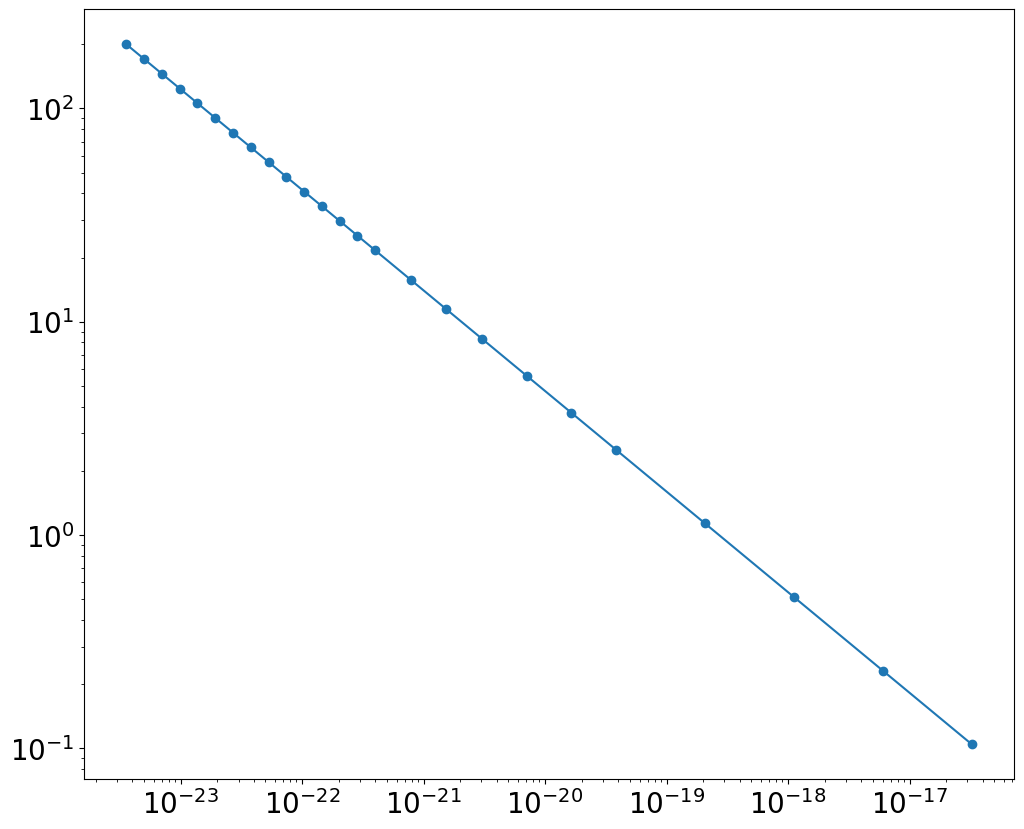

In [67]:

df = pd.read_csv('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/Neutron_bg/flux/new_flux.txt', delim_whitespace=True,  names=['1', '2'])
x = df['1']
y = df['2']
print(df)

plt.plot(y, x, marker='o')
plt.yscale('log')
plt.xscale('log')



<AxesSubplot:>

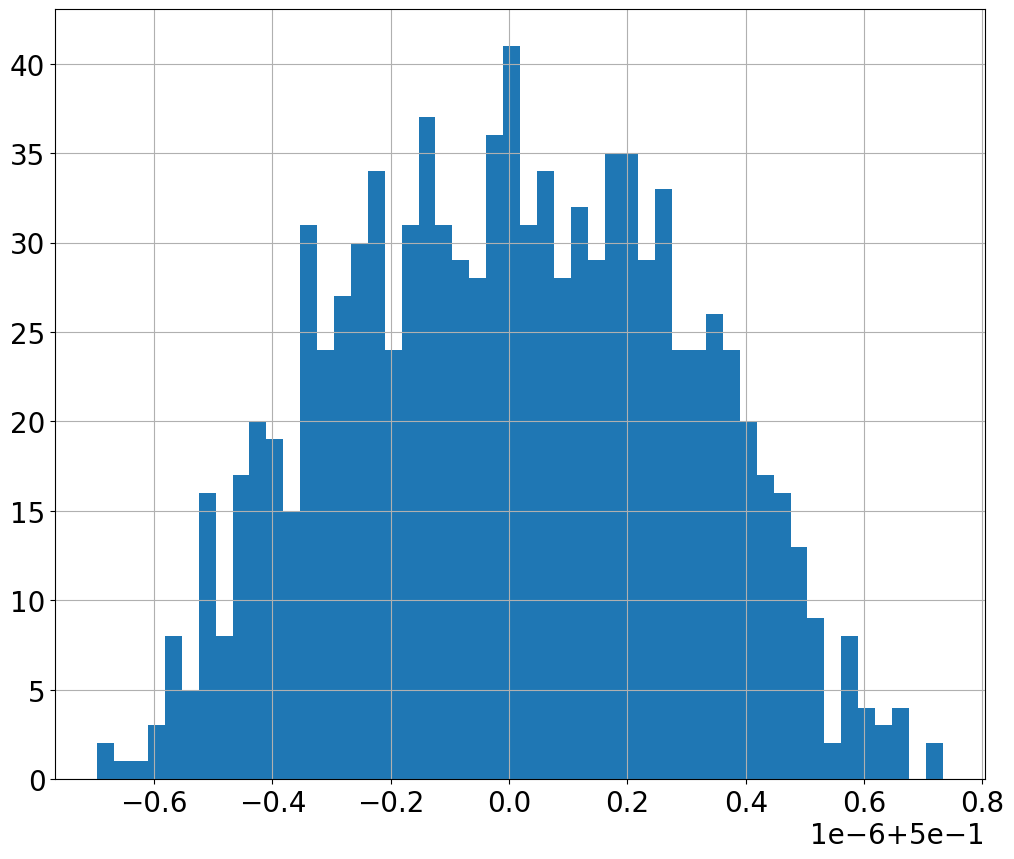

In [48]:
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour activer la 3D

df = pd.read_csv('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/Neutron_bg/check_pos.txt', delim_whitespace=True,  names=['x','y', 'z'])
df['norm'] = (df['x']**2 + df['y']**2 + df['z']**2)**1/2
df_norm = df['norm']
df_norm.hist(bins=50)



In [4]:
pressure = [5.0]
#pressure = np.arange(2, 8.5, 0.5)
bins = np.arange(0, 20, 1)
print(pressure)
ratio_store = []
for i in range(len(pressure)):
    filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_1000000_alu.h5'

    #filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/xenon/GaP_Fe55_Xenon_Alu_'+str(pressure[i])+'.h5'
    #filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/argon/1000000evts_Argon/GaP_Fe55_Argon_Alu_'+str(pressure[i])+'.h5'
    print(filepath_wf)
    hits = pd.read_hdf(filepath_wf, "/MC/hits")
    particles = pd.read_hdf(filepath_wf, "/MC/particles")
    print(len(particles))
    gamma = particles[(particles['particle_name'] == 'gamma')]
    gamma_keV = gamma['kin_energy'] * 1000
    edep = hits['energy']
    print(hits)
    edep = hits[(hits['label'] == 'DRIFT')]
    print(edep)
    edep = edep * 1e3
    #counts, bins, patches = plt.hist(gamma_keV, bins = 20)
    counts, bins, patches = plt.hist(edep, bins = bins)

    #plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
    #plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
    #plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
    #plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
    #plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
    #plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
    #plt.axvline(5.89, color='red', linestyle='-', linewidth=2)
    #plt.axvline(6.49, color='red', linestyle='-', linewidth=2)
    plt.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')
    plt.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
    plt.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
    plt.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
    #plt.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
    plt.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
    plt.yscale('log')
    plt.ylabel('Entries')
    plt.xlabel('Energy (keV)')
    plt.legend(loc='upper left')



    count_store = []

    for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
        bin_center = (bin_left + bin_right) / 2
        #plt.text(bin_center, count, str(int(count)), ha='center', va='bottom', fontsize=20)
        count_store.append(count)
    print(str(int(count_store[1])))
    print(str(int(count_store[6])))
    print("The ratio between the 5.9keV and the 1.4keV peaks is : ", count_store[6]/count_store[1])
    ratio_store.append(count_store[6]/count_store[1])
    plt.show()


#plt.yscale('log')



[5.0]
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_1000000_alu.h5


HDF5ExtError: HDF5 error back trace

  File "H5F.c", line 836, in H5Fopen
    unable to synchronously open file
  File "H5F.c", line 796, in H5F__open_api_common
    unable to open file
  File "H5VLcallback.c", line 3863, in H5VL_file_open
    open failed
  File "H5VLcallback.c", line 3675, in H5VL__file_open
    open failed
  File "H5VLnative_file.c", line 128, in H5VL__native_file_open
    unable to open file
  File "H5Fint.c", line 1965, in H5F_open
    unable to read superblock
  File "H5Fsuper.c", line 617, in H5F__super_read
    truncated file: eof = 96, sblock->base_addr = 0, stored_eof = 2048

End of HDF5 error back trace

Unable to open/create file '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_1000000_alu.h5'

In [94]:
#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_2.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_100000.h5'

    
config = pd.read_hdf(filepath_wf, "/MC/configuration")
print(config)

                                 param_key                  param_value
0                               event_type                        other
1                               num_events                       100000
2                             saved_events                         2585
3                       interacting_events                         2585
4                              Pmt_binning                 0.100000 mus
5             /PhysicsList/RegisterPhysics  G4EmStandardPhysics_option4
6             /PhysicsList/RegisterPhysics               G4DecayPhysics
7             /PhysicsList/RegisterPhysics    G4RadioactiveDecayPhysics
8             /PhysicsList/RegisterPhysics             G4OpticalPhysics
9             /PhysicsList/RegisterPhysics                 NexusPhysics
10            /PhysicsList/RegisterPhysics         G4StepLimiterPhysics
11       /nexus/RegisterPersistencyManager           PersistencyManager
12                /nexus/RegisterRunAction             DefaultRu

Text(0.5, 1.0, 'Argon (1000000evts)')

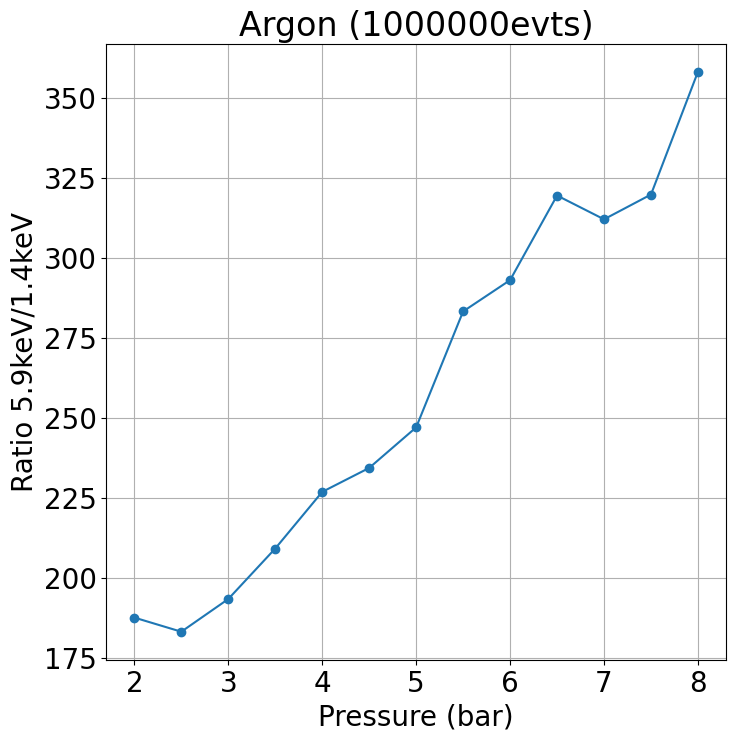

In [7]:
plt.figure(figsize=(8, 8))
plt.plot(pressure, ratio_store, marker='o')
plt.grid(True)

plt.xlabel('Pressure (bar)')
plt.ylabel('Ratio 5.9keV/1.4keV')
plt.title('Argon (1000000evts)')

In [260]:
##Load data
import seaborn as sns

# -------------------------
# Style Seaborn
# -------------------------
sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("deep")

run_nb = [53]

edep_plot = []
edep_sm_plot = []

kin_ene_plot = []
kin_ene_sm_plot = []
kin_ene_sm = []

#Parameters for smearing
energy = 5.9

# Which energy do we calculate ? 
edep_process = False
kin_ene_process = True


sigma_init = 0.352 #sigma Xe data 
#sigma_init = 0.499 #sigma Ar data 

for i in range(len(run_nb)):
    
    print(run_nb[i])
    
    filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_'+str(run_nb[i])+'.h5'

    
    hits = pd.read_hdf(filepath_wf, "/MC/hits")
    particles = pd.read_hdf(filepath_wf, "/MC/particles")
    
    os.makedirs("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/Run_"+str(run_nb[i]), exist_ok=True)
    
    if edep_process == True:
        ##### EDEP ####

        #Load edep info
        event_id = hits['event_id']
        event_max = event_id.max()


        #Only events in Drift volume
        edep_store = []
        edep = hits[(hits['label'] == 'DRIFT') | (hits['label'] == 'AluFoil') | (hits['label'] == 'SourceBox')]
        edep['energy_kev'] = edep['energy'] * 1e3

        #Sum of edep for independent events
        for j in range(0, event_max):
            edep2 = edep[(edep['event_id'] == j)]
            edep_store.append(edep2.energy_kev.sum())

        #Store edep of each events for plot distribution
        edep_store = np.array(edep_store)

        #We store in other variable in order to not loose original edep (long loading time)
        edep_store1 = edep_store
        edep_store1 = np.array(edep_store1)

        #Smearing: we multiply each energy by a gaussian of mean=1 and a sigma according to data 
        for k in range(len(edep_store1)):
            sigma_smear = np.sqrt(edep_store[k]/energy)*sigma_init
            edep_store1[k] = np.random.normal(edep_store[k], sigma_smear, 1)

        # We store the raw and smeared energy for plots
        edep_sm_plot.append(edep_store1)
        edep_plot.append(edep_store)

        # We save in txt files because calculation time is very long
        np.savetxt("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/Run_"+str(run_nb[i])+"/Run_"+str(run_nb[i])+"_edep_raw.txt", edep_store)
        np.savetxt("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/Run_"+str(run_nb[i])+"/Run_"+str(run_nb[i])+"_edep_sm.txt", edep_store1)

    
    if kin_ene_process == True:
        ##### Kin ene ####

        #Load usefull info for kin ene distrib
        #fe55_process1 = particles[(particles['creator_proc'] == 'RadioactiveDecay') | (particles['creator_proc'] == 'phot') ]
        #fe55_process = fe55_process1[(fe55_process1['particle_name'] == 'gamma')]
        fe55_process = particles[(particles['particle_name'] == 'gamma')]# & (particles['particle_name'] == 'gamma')]

        # We store Kin ene infos
        kin_ene_keV = fe55_process['kin_energy'] * 1e3
        kin_ene_keV = np.array(kin_ene_keV)

        # We define an array with same dimensions as kin_ene_keV to prepare smearing
        kin_ene_sm = kin_ene_keV * 0

        # Smearing of kin ene
        for L in range(len(kin_ene_keV)):
            sigma_smear = np.sqrt(kin_ene_keV[L]/energy)*sigma_init
            kin_ene_sm[L] = np.random.normal(kin_ene_keV[L], sigma_smear, 1)

        # We store the raw and smeared energy for plots
        kin_ene_plot.append(kin_ene_keV)
        kin_ene_sm_plot.append(kin_ene_sm)

        np.savetxt("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/Run_"+str(run_nb[i])+"/Run_"+str(run_nb[i])+"_ke_raw.txt", kin_ene_keV)
        np.savetxt("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/Run_"+str(run_nb[i])+"/Run_"+str(run_nb[i])+"_ke_sm.txt", kin_ene_sm)


53


[array([5.8586826, 5.8479276, 5.8479114, ..., 6.450098 , 5.847941 ,
       6.4501343], dtype=float32)]
[0.03 0.05 0.06 0.08 0.09 0.1  0.11 0.13 0.14 0.2  0.25 0.3  0.53 0.54
 0.56 0.57 0.59 0.6  0.64 0.65 0.66 0.67 0.68 0.7  0.71 0.72 0.78 0.86
 0.9  0.92 0.96 0.97 1.11 1.47 3.65 3.79 3.85 3.98 4.08 4.1  4.18 4.41
 4.43 4.49 4.57 4.61 4.7  4.71 4.73 4.74 4.75 4.9  5.03 5.08 5.26 5.27
 5.35 5.4  5.41 5.85 5.86 6.45 6.5 ]
[5.8773365 6.0414853 5.6485476 ... 6.4142833 5.578571  6.6447573]


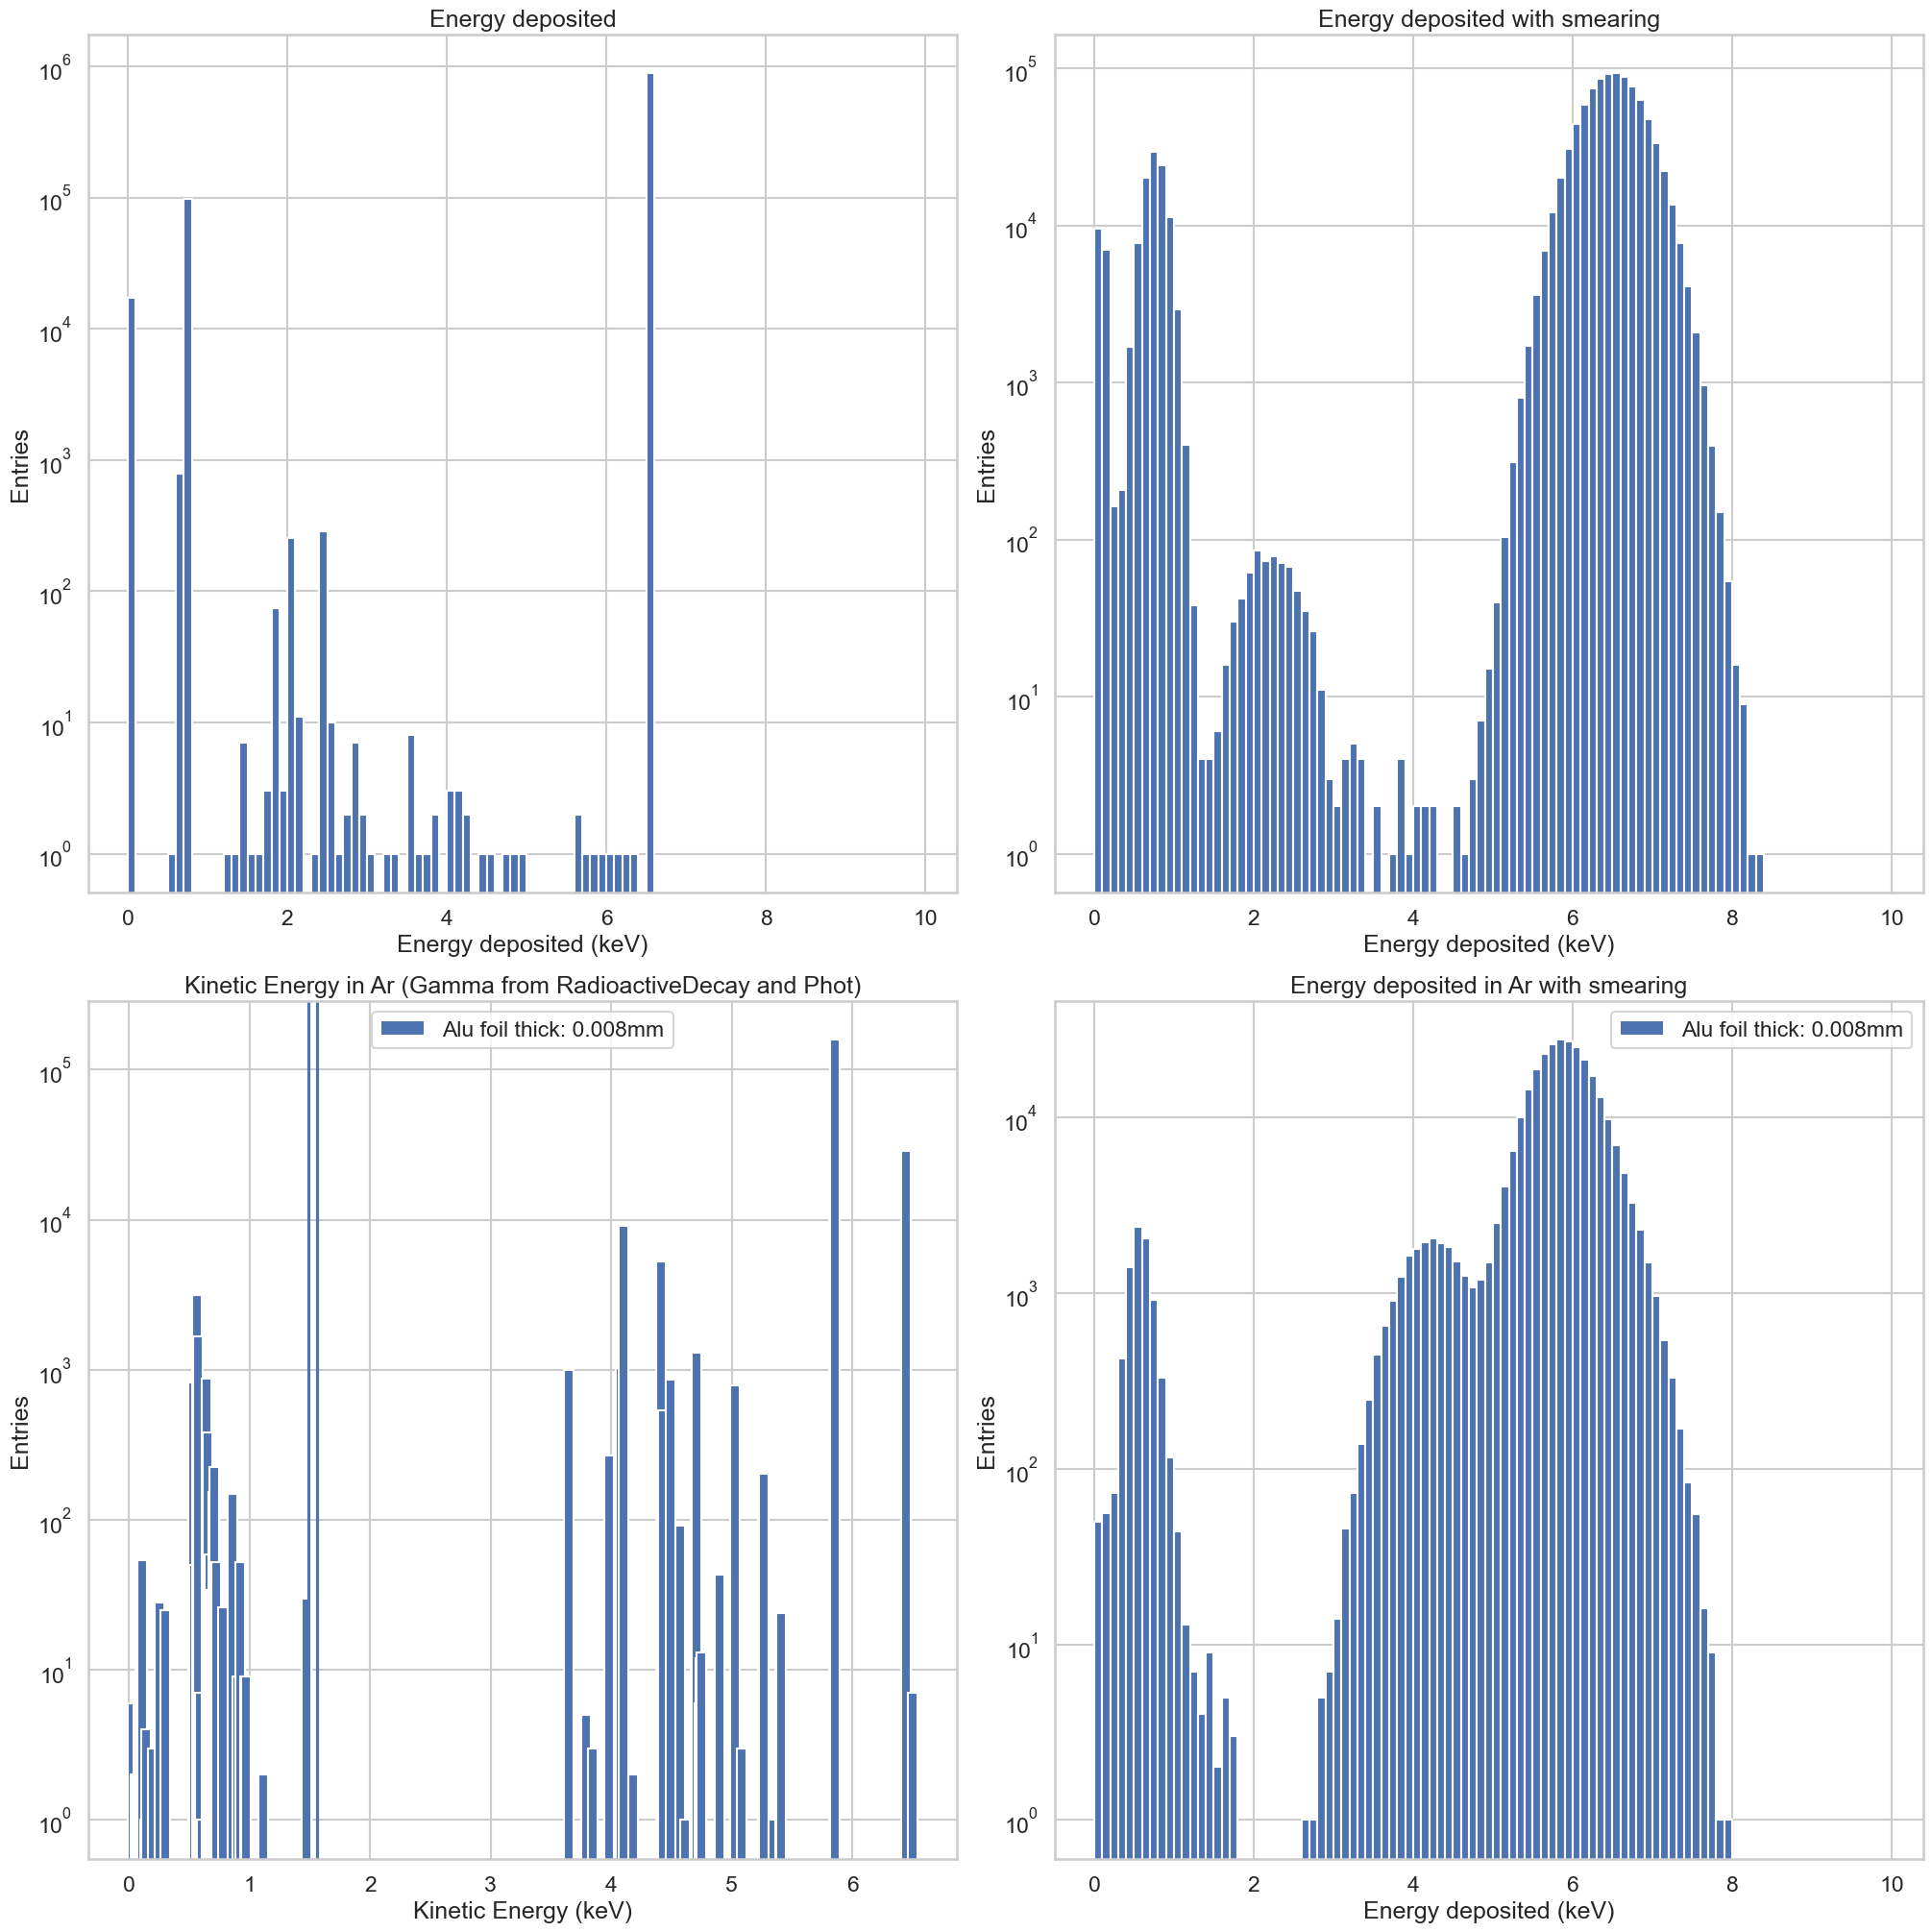

In [123]:
size_plot = 10
row = 2*len(run_nb)
col = 2
fig, axes = plt.subplots(row, col, figsize=(size_plot * col ,size_plot * row), constrained_layout=True)
axes = axes.flatten()

#legend = ['Xe', 'Ar']
legend = ['0.008', '0.015', '0.020', '0.025', '0.5', '1']
for i in range(len(run_nb)):
    bins = np.arange(0, 10, 0.1)
    
    #plots of edep before and after smearing
    
    axes[i*4].hist(edep_plot[i], bins = bins, density=False)
    
    axes[i*4].set_xlabel('Energy deposited (keV)')
    axes[i*4].set_ylabel('Entries')
    axes[i*4].set_yscale('log')
    axes[i*4].set_title('Energy deposited')
    
    axes[i*4 + 1].hist(edep_sm_plot[i], bins = bins, density=False)
    
    axes[i*4 + 1].set_xlabel('Energy deposited (keV)')
    axes[i*4 + 1].set_ylabel('Entries')
    axes[i*4 + 1].set_yscale('log')
    axes[i*4 + 1].set_title('Energy deposited with smearing')
    
    #plots of kin energy before and after smearing
    print(kin_ene_plot)
    kin_ene_plot_rounded = np.round(kin_ene_plot[i], 2)
    
    values, counts = np.unique(kin_ene_plot_rounded, return_counts=True)
    
    
    axes[i*4 + 2].bar(values, counts, width=0.08, label='Alu foil thick: ' + legend[i]+'mm')
    #axes[i*4 + 2].bar(values, counts, width=0.08, alpha=1)
    print(values)
    
    axes[i*4 + 2].set_xlabel('Kinetic Energy (keV)')
    axes[i*4 + 2].set_ylabel('Entries')
    axes[i*4 + 2].set_yscale('log')
    axes[i*4 + 2].set_title('Kinetic Energy in Ar (Gamma from RadioactiveDecay and Phot)')
    axes[i*4 + 2].axvline(1.486)
    axes[i*4 + 2].axvline(1.557)
    axes[i*4 + 2].legend()
    
    axes[i*4 + 3].hist(kin_ene_sm_plot[i], bins = bins, density=False, label='Alu foil thick: ' + legend[i]+'mm')
    print(kin_ene_sm_plot[i])
    axes[i*4 + 3].set_yscale('log')
    axes[i*4 + 3].set_xlabel('Energy deposited (keV)')
    axes[i*4 + 3].set_ylabel('Entries')
    axes[i*4 + 3].set_title('Energy deposited in Ar with smearing')
    axes[i*4 + 3].legend()
    
    
   # kin_ene_plot
    
    
    

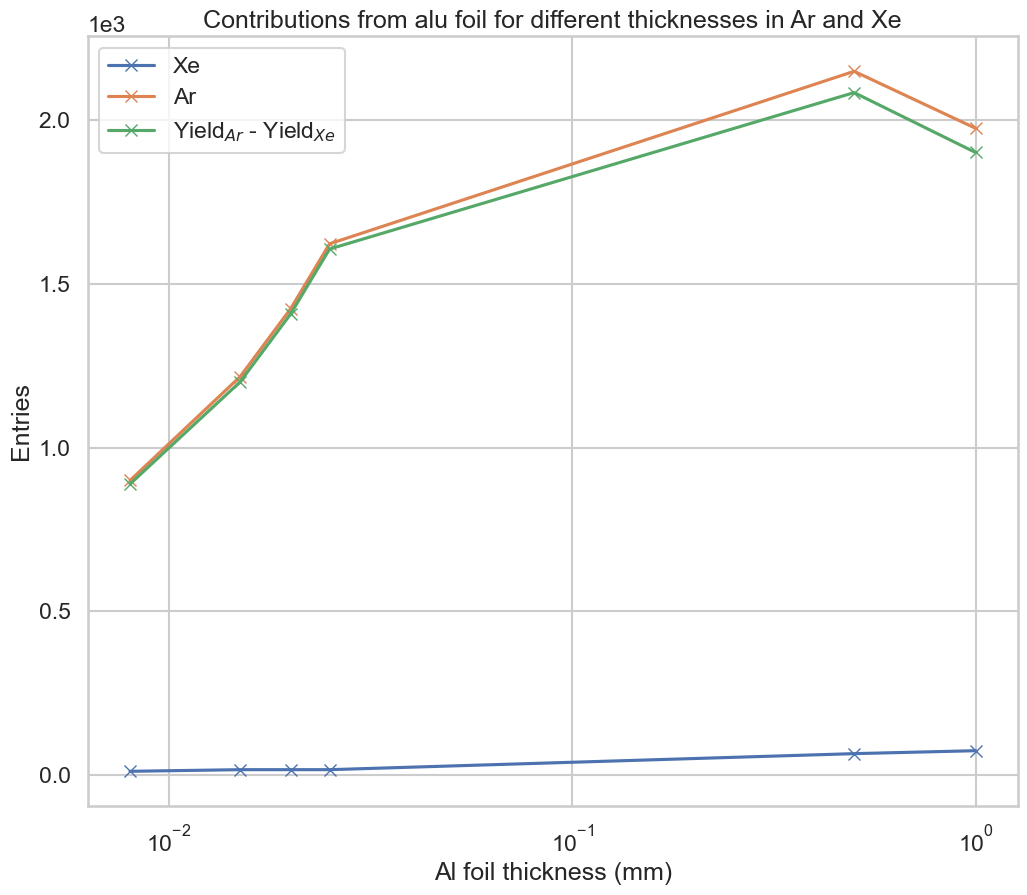

Text(0.5, 0, 'Al foil thickness (mm)')

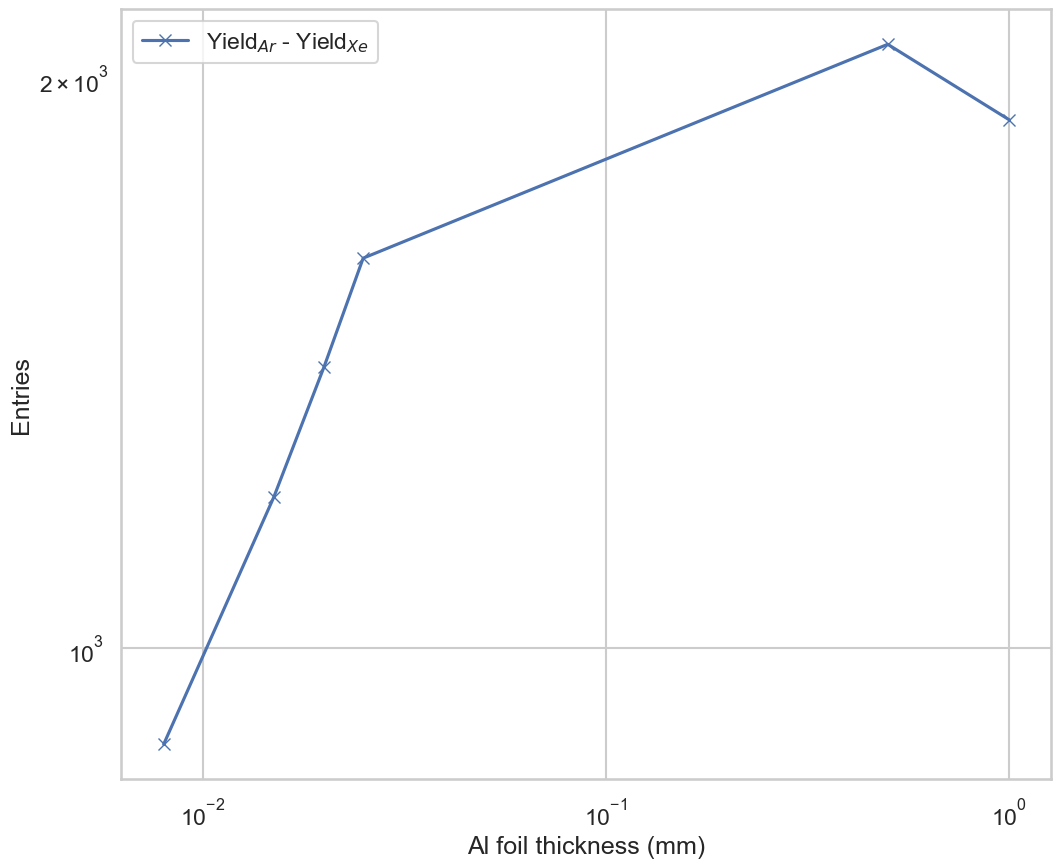

In [89]:
counts_alu = []

alu_thick = [0.008, 0.015, 0.020, 0.025, 0.5, 1]
legend = ['0.008', '0.015', '0.020', '0.025', '0.5', '1']

for i in range(len(run_nb)):

    kin_ene_plot_rounded = np.round(kin_ene_plot[i], 2)

    values, counts = np.unique(kin_ene_plot_rounded, return_counts=True)
    alu_ene = (values >= 1.4) & (values <= 1.6)
    
    counts_alu.append(np.sum(counts[alu_ene]))

    #axes[i*4 + 2].bar(values, counts, width=0.08, label=legend[i])
plt.plot(alu_thick, counts_alu_xe, marker='x', label='Xe')
plt.plot(alu_thick, counts_alu, marker='x', label='Ar')
plt.plot(alu_thick, diff, marker='x', label='Yield$_{Ar}$ - Yield$_{Xe}$')
plt.xlabel('Al foil thickness (mm)')
plt.title('Contributions from alu foil for different thicknesses in Ar and Xe')
plt.ylabel('Entries')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.show()

counts_alu = np.array(counts_alu)
counts_alu_xe = np.array(counts_alu_xe)

diff = counts_alu - counts_alu_xe

plt.plot(alu_thick, diff, marker='x', label='Yield$_{Ar}$ - Yield$_{Xe}$')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Entries')
plt.legend()
plt.xlabel('Al foil thickness (mm)')
#counts_alu_xe = counts_alu #data saved for scan thick alu Xe

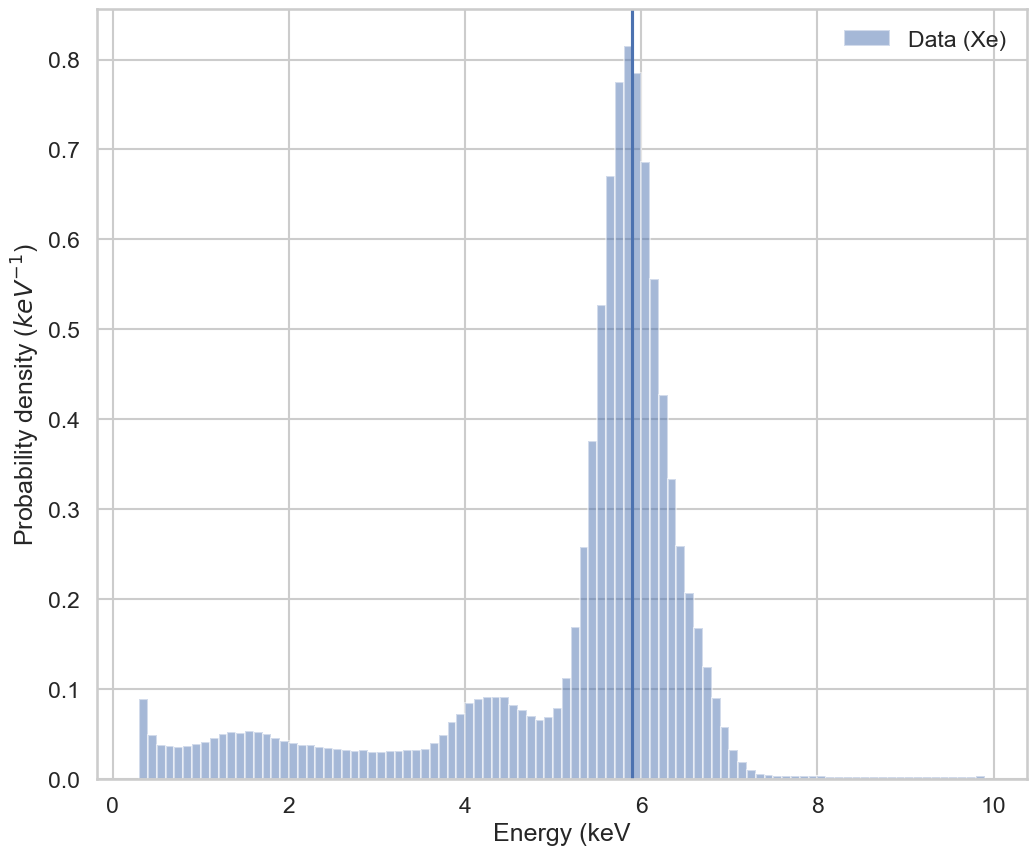

In [261]:
#overlap between data and g4 results
bins = np.arange(0.3, 10, 0.1)
ene_data = np.loadtxt("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/data/Xe_8.5bar_data.txt")
ene_g4 = np.loadtxt("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/GaP_G4/Run_53/Run_53_ke_sm.txt")

plt.hist(ene_data, bins=bins, density=True, alpha=0.5, label='Data (Xe)')
#plt.hist(ene_g4, bins=bins, density=True, alpha=0.5, label='G4 (Xe)')
plt.xlabel('Energy (keV')
plt.ylabel('Probability density ($keV^{-1}$)')
plt.axvline(5.9)
plt.legend()

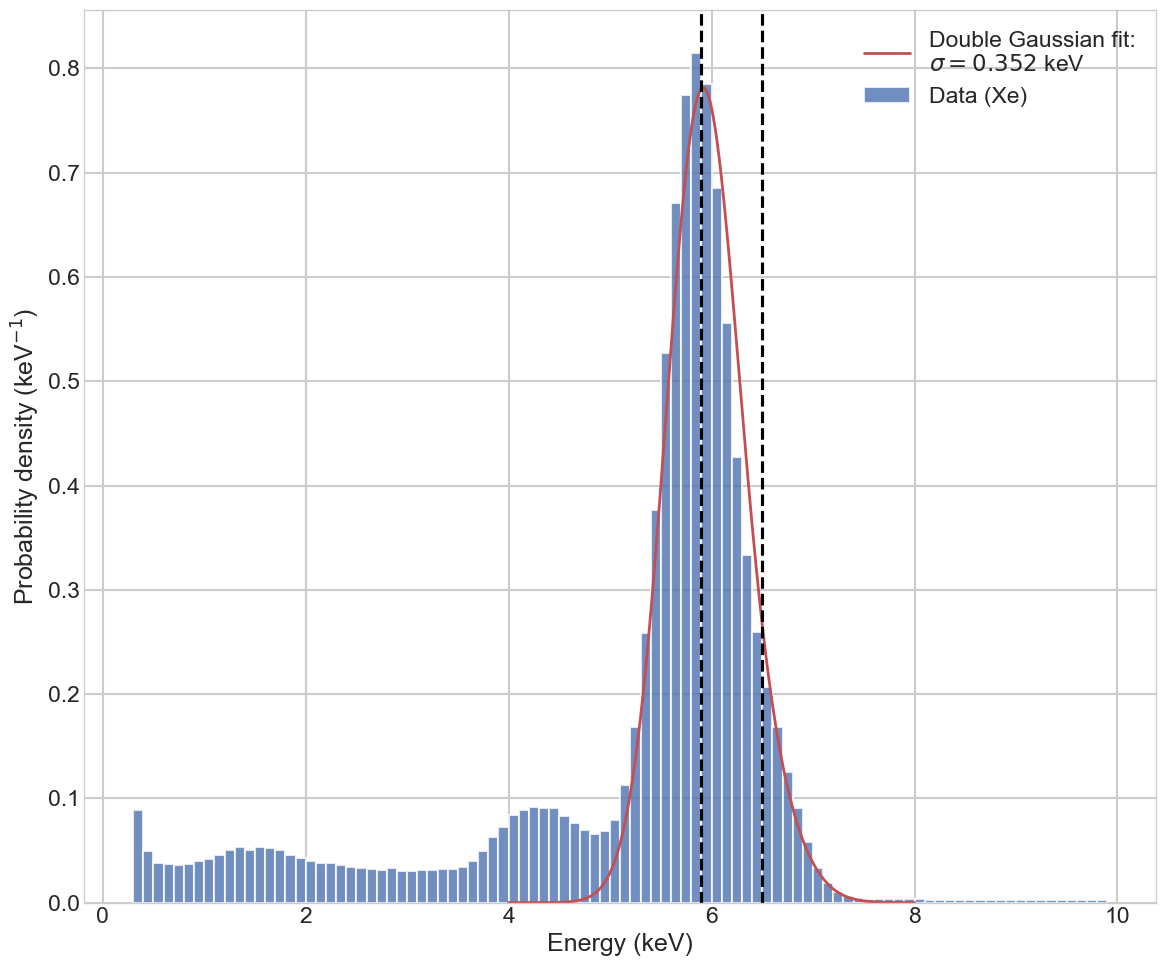

In [265]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Données physiques
centers   = np.array([5.9, 6.5])
int_ratio = np.array([11142, 1299])

ratio = int_ratio[1] / int_ratio[0]  # rapport secondaire / principal

# Histogram bins
bins = np.arange(0.3, 10, 0.1)

# Histogramme
counts, bin_edges, _ = plt.hist(
    ene_data,
    bins=bins,
    density=True,
    alpha=0.8,
    label="Data (Xe)"
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# --- Double gaussienne contrainte ---
def double_gaussian(x, A, sigma):
    g1 = A * np.exp(-(x - centers[0])**2 / (2 * sigma**2))
    g2 = A * ratio * np.exp(-(x - centers[1])**2 / (2 * sigma**2))
    return g1 + g2

# Fenêtre de fit
mask = (bin_centers > 4.0) & (bin_centers < 8.0)
x_fit = bin_centers[mask]
y_fit = counts[mask]

# Guess initial
p0 = [max(y_fit), 0.2]

# Fit
params, cov = curve_fit(double_gaussian, x_fit, y_fit, p0=p0)
A_fit, sigma_fit = params

# Courbe lissée
x_smooth = np.linspace(4.0, 8.0, 500)
y_smooth = double_gaussian(x_smooth, A_fit, sigma_fit)

plt.plot(
    x_smooth,
    y_smooth,
    "r-",
    linewidth=2,
    label=fr"Double Gaussian fit:" "\n"
          fr"$\sigma={sigma_fit:.3f}$ keV"
)

# Lignes des centres
plt.axvline(5.9, color="black", linestyle="--")
plt.axvline(6.5, color="black", linestyle="--")

plt.xlabel("Energy (keV)")
plt.ylabel(r"Probability density (keV$^{-1}$)")
plt.legend()
plt.tight_layout()
plt.show()

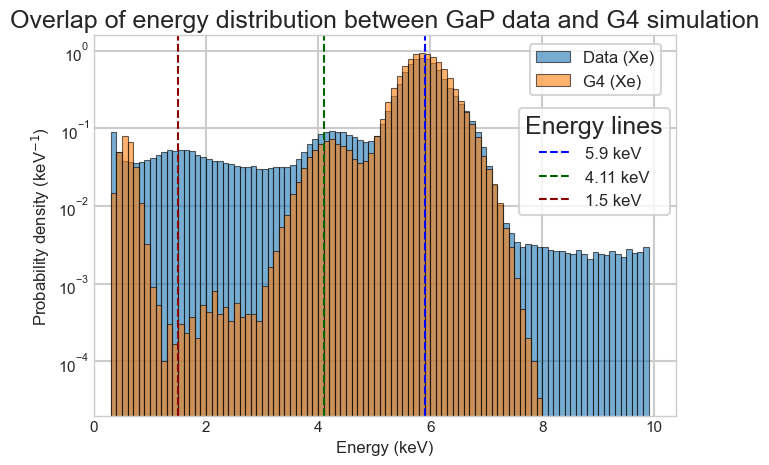

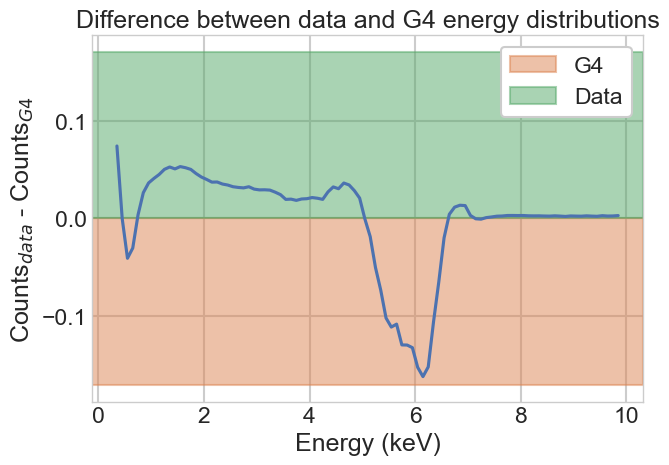

In [264]:
#clean plot comparison data and g4

plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize=(7,5))

# Histogrammes
h1, bin_edges, patches = ax.hist(ene_data, bins=bins, density=True,
             alpha=0.6, color="#1f77b4",
             edgecolor="black", linewidth=0.8,
             label="Data (Xe)")

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

h2, bin_edges, patches = ax.hist(ene_g4, bins=bins, density=True,
             alpha=0.6, color="#ff7f0e",
             edgecolor="black", linewidth=0.8,
             label="G4 (Xe)")
diff = h1 - h2

# Lignes verticales (on stocke les handles)
l1 = ax.axvline(5.9, color="blue", linestyle="--", linewidth=1.5)
l2 = ax.axvline(4.11, color="darkgreen", linestyle="--", linewidth=1.5)
l3 = ax.axvline(1.5, color="darkred", linestyle="--", linewidth=1.5)

# Labels axes
ax.set_xlabel("Energy (keV)", fontsize=12)
ax.set_ylabel(r"Probability density (keV$^{-1}$)", fontsize=12)
ax.tick_params(axis="both", labelsize=11)
ax.set_xlim(left=0)
ax.set_yscale('log')
ax.set_title('Overlap of energy distribution between GaP data and G4 simulation')

# Première légende : histogrammes
legend1 = ax.legend(bbox_to_anchor=(0.735, 1), frameon=True, fontsize=12)
ax.add_artist(legend1)

# Deuxième légende : lignes d’énergie
ax.legend([l1, l2, l3],
          ["5.9 keV", "4.11 keV", "1.5 keV"],
          loc="upper center",
          bbox_to_anchor=(0.86, 0.83),
          frameon=True,
          title="Energy lines", fontsize=12)

plt.tight_layout()
plt.show()

fig1, ax1 = plt.subplots(figsize=(7,5))

ax1.errorbar(bin_centers, diff)
ax1.axhspan(0, -0.17, color='C11', alpha=0.5, label='G4')
ax1.axhspan(0, 0.17, color='C12', alpha=0.5, label='Data')
ax1.legend(frameon=True, framealpha=1)
ax1.set_xlabel('Energy (keV)')
ax1.set_ylabel('Counts$_{data}$ - Counts$_{G4}$')
ax1.set_title('Difference between data and G4 energy distributions')

plt.tight_layout()
plt.show()

In [609]:
# To load and analyze a signle run
run = 53 #xe
#run = 54 #ar
#run=55

filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_'+str(run)+'.h5'

    
hits = pd.read_hdf(filepath_wf, "/MC/hits")
particles = pd.read_hdf(filepath_wf, "/MC/particles")



/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_1811/857139364.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fe55_process['energy_kev'] = fe55_process['kin_energy'] * 1e3
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_1811/857139364.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fe55_process["kin_energy_round"] = fe55_process["energy_kev"].round(1)


                  size
initial_volume        
AluFoil             30
GasDrift        297966
sourcePlate          2 3


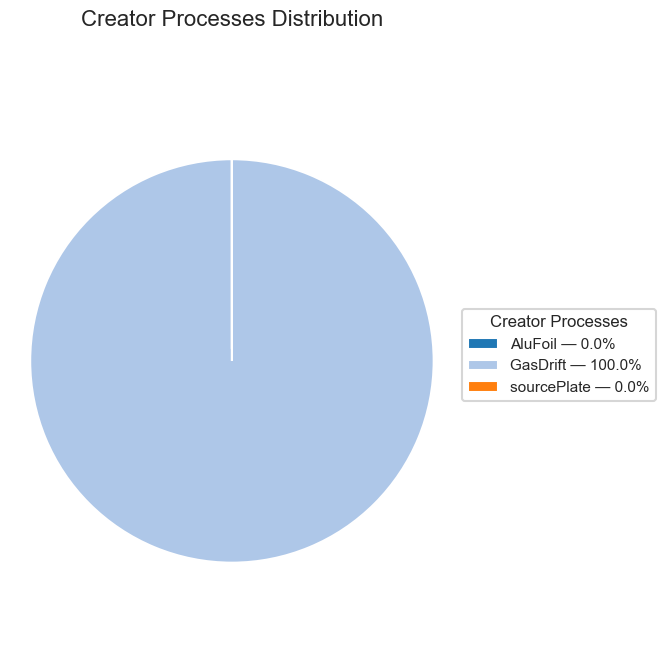

Energy :  1.5
event_id 76055         6147
510617       41228
690294       55673
1723630     139381
1930560     156053
2373409     191830
2821219     227929
2831224     228734
3574969     288803
3824291     308967
4079426     329515
4087883     330188
4675028     377446
5089397     410940
5192220     419270
6455617     521421
6710437     542045
7603199     614055
7818333     631399
8086537     653232
8202121     662670
8284228     669336
8808489     711731
9021861     728954
9617038     777197
10123340    818047
10993087    888414
11885143    960628
11943129    965313
12307569    994639
Name: event_id, dtype: int64


In [663]:
# Load energy kinetic of gammas and do analysis per energy peak

# We load energy kinetic of gammas and we group by decimals
fe55_process = particles[ (particles['particle_name'] == 'gamma')]# & (particles['particle_name'] == 'gamma')]
#fe55_process1 = particles[(particles['creator_proc'] == 'RadioactiveDecay') | (particles['creator_proc'] == 'phot') ]
#fe55_process = fe55_process1[(fe55_process1['particle_name'] == 'gamma')]
#print(fe55_process)
fe55_process['energy_kev'] = fe55_process['kin_energy'] * 1e3
fe55_process["kin_energy_round"] = fe55_process["energy_kev"].round(1)
fe55_process_peak = fe55_process.groupby('kin_energy_round')['kin_energy_round'].agg(['size'])

name_study = 'initial_volume'

element_tot = fe55_process.groupby(name_study)[name_study].agg(['size'])
group_names = element_tot.index

print(element_tot, len(element_tot))
labels = []
for label in group_names:
    labels.append(str(label))



sizes = element_tot['size'].values
labels = element_tot.index.tolist()

# Calcul des pourcentages
total = np.sum(sizes)
percentages = 100 * sizes / total

# Couleurs
colors = plt.cm.tab20.colors[:len(sizes)]

fig, ax = plt.subplots(figsize=(7,7))

wedges, texts = ax.pie(
    sizes,
    startangle=90,
    colors=colors,
    explode=[0.03]*len(sizes),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Création des labels de légende avec %
legend_labels = [
    f"{label} — {pct:.1f}%"
    for label, pct in zip(labels, percentages)
]

ax.legend(
    wedges,
    legend_labels,
    title="Creator Processes",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

ax.set_title("Creator Processes Distribution", fontsize=16, pad=20)

ax.axis('equal')

plt.tight_layout()
plt.show()


x = fe55_process_peak.reset_index()['kin_energy_round'].tolist()
x = np.array(x)

rangemin = 1.3
rangemax = 1.7

ene_range_filter = (x>=rangemin) & (x<=rangemax)

x = x[ene_range_filter]

size_plot = 10
row = 2*len(x)
col = 2
#fig, axes = plt.subplots(row, col, figsize=(size_plot * col ,size_plot * row), constrained_layout=True)
#axes = axes.flatten()

values_store = []
labels_store = []
event_id_store = []
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

for i in range(len(x)):
    ene_range = fe55_process[(fe55_process["kin_energy_round"] == x[i])]
    print('Energy : ', x[i])
    print('event_id', ene_range['event_id'])
    event_id_store.append(ene_range['event_id'])
    #print('creator proc : ', ene_range['creator_proc'])
    #print('Initial volume : ', ene_range['initial_volume'])
    #print('final volume : ', ene_range['final_volume'])
    element = ene_range.groupby(name_study)[name_study].agg(['size'])
    #element_tot = fe55_process.groupby(name_study)[name_study].agg(['size'])
    labels = element.index.tolist()
    labels_store.append(labels)

    values = element['size']
    values_store.append(values)

    #print(element)
    
    
    

    
    
    

In [669]:
# Print reduced dataset for event reconstruction
print(event_id_store)
event_id = np.concatenate(event_id_store)
#event_id = event_id_store[0]

event_id = np.array(event_id)
print(event_id)

dst = particles[['event_id', "particle_name", "particle_id", "primary", "mother_id", "initial_volume",
                "final_volume", "kin_energy", "creator_proc", "final_proc"]]
dst['kin_energy_kev'] = dst['kin_energy'] * 1e3
for i in range(len(event_id)):
    ev_id_sel = dst[dst['event_id'] == event_id[i]]
    print(ev_id_sel)
    print('new loop \n\n\n')

[76055         6147
510617       41228
690294       55673
1723630     139381
1930560     156053
2373409     191830
2821219     227929
2831224     228734
3574969     288803
3824291     308967
4079426     329515
4087883     330188
4675028     377446
5089397     410940
5192220     419270
6455617     521421
6710437     542045
7603199     614055
7818333     631399
8086537     653232
8202121     662670
8284228     669336
8808489     711731
9021861     728954
9617038     777197
10123340    818047
10993087    888414
11885143    960628
11943129    965313
12307569    994639
Name: event_id, dtype: int64]
[  6147  41228  55673 139381 156053 191830 227929 228734 288803 308967
 329515 330188 377446 410940 419270 521421 542045 614055 631399 653232
 662670 669336 711731 728954 777197 818047 888414 960628 965313 994639]
       event_id particle_name  particle_id  primary  mother_id initial_volume  \
76046      6147          Fe55            1        1          0       GasDrift   
76047      6147        

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_1811/3738290004.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dst['kin_energy_kev'] = dst['kin_energy'] * 1e3


In [ ]:
# Look at the 3D distribution of interaction





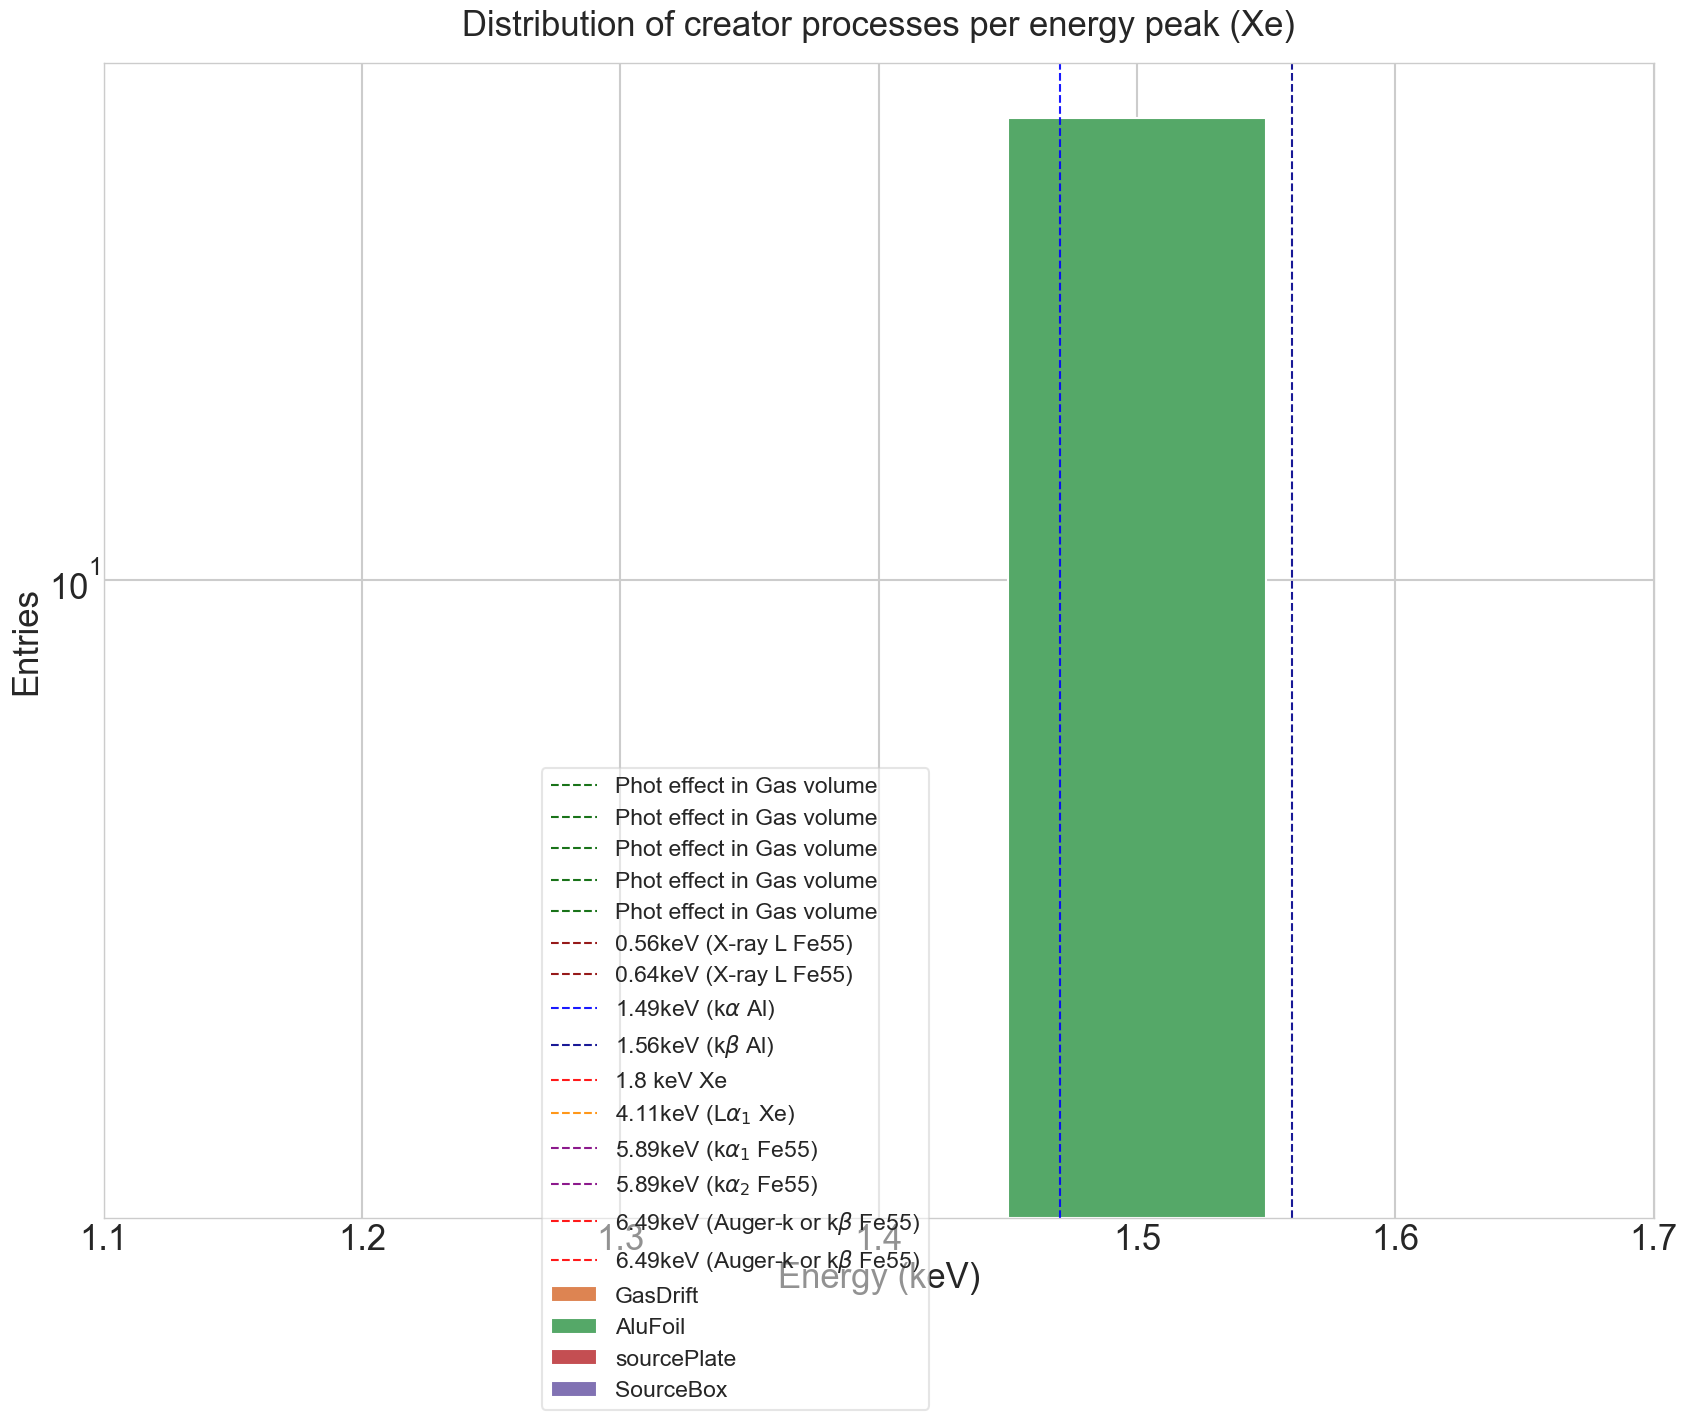

In [665]:
#plot processes per energy peaks Xe

# Largeur des barres
width = 0.1

fig, ax = plt.subplots(figsize=(20,15))

for i in range(len(x)):

    values = values_store[i]
    #print(values)
    #print(x)
    
    for j in range(len(labels_store[i])):
        #print(labels_store)
        if name_study == 'creator_proc':
            if labels_store[i][j] == 'RadioactiveDecay':
                color='C1'
            if labels_store[i][j] == 'phot':
                color='C2'
            if labels_store[i][j] == 'eBrem':
                color='C3'
                
        
        
        if name_study == 'initial_volume':
            if labels_store[i][j] == 'GasDrift':
                color='C1'
            if labels_store[i][j] == 'AluFoil':
                color='C2'
            if labels_store[i][j] == 'sourcePlate':
                color='C3'
            if labels_store[i][j] == 'SourceBox':
                color='C4'

        
        
        ax.bar(x[i], values[j],
               width=width,
               bottom=bottom, color=color)
        
if name_study == 'creator_proc':
    ax.bar(100, 10,bottom=bottom, label='RadioDecay', color='C1')
    ax.bar(100, 10,bottom=bottom,label='PhotElectric', color='C2')
    ax.bar(100, 10,bottom=bottom, label='eBrem', color='C3')

if name_study == 'initial_volume':
    ax.bar(100, 10,bottom=bottom, label='GasDrift', color='C1')
    ax.bar(100, 10,bottom=bottom,label='AluFoil', color='C2')
    ax.bar(100, 10,bottom=bottom, label='sourcePlate', color='C3')
    ax.bar(100, 10,bottom=bottom, label='SourceBox', color='C4')

ax.set_xlim(rangemin-0.2, rangemax)


ax.set_xlabel('Energy (keV)', fontsize=25)
ax.set_ylabel('Entries', fontsize=25)
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=25)
ax.set_yscale('log')
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.set_title(
    "Distribution of creator processes per energy peak (Xe)",
    pad=20 , fontsize=25 # augmente la distance
)

# --- Lignes de référence ---
lines = [
    (0.064,  "Phot effect in Gas volume", "darkgreen"),
    (0.6,  "Phot effect in Gas volume", "darkgreen"),
    (0.21,  "Phot effect in Gas volume", "darkgreen"),
    (0.22,  "Phot effect in Gas volume", "darkgreen"),
    (0.3,  "Phot effect in Gas volume", "darkgreen"),
    (0.56,  "0.56keV (X-ray L Fe55)", "darkred"),
    (0.64,  "0.64keV (X-ray L Fe55)", "darkred"),
    (1.47, "1.49keV (k$\\alpha$ Al)", "blue"),
    (1.56, "1.56keV (k$\\beta$ Al)", "darkblue"),
    (1.8,   "1.8 keV Xe", "red"),
    #(2.955, "2.96keV (k$\\alpha$ Ar)", "orange"),
    #(3.19,  "3.19keV (k$\\beta$ Ar)", "darkorange"),
    (4.1,  "4.11keV (L$\\alpha_{1}$ Xe)", "darkorange"),
    (5.8,  "5.89keV (k$\\alpha_{1}$ Fe55)", "purple"),
    (5.9,  "5.89keV (k$\\alpha_{2}$ Fe55)", "purple"),
    (6.4,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    (6.5,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    
]

for energy, label, color in lines:
    ax.axvline(
        energy,
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.9,
        label=label
    )
plt.legend(bbox_to_anchor=(0.54, 0.40), frameon = True, framealpha=0.5)
    




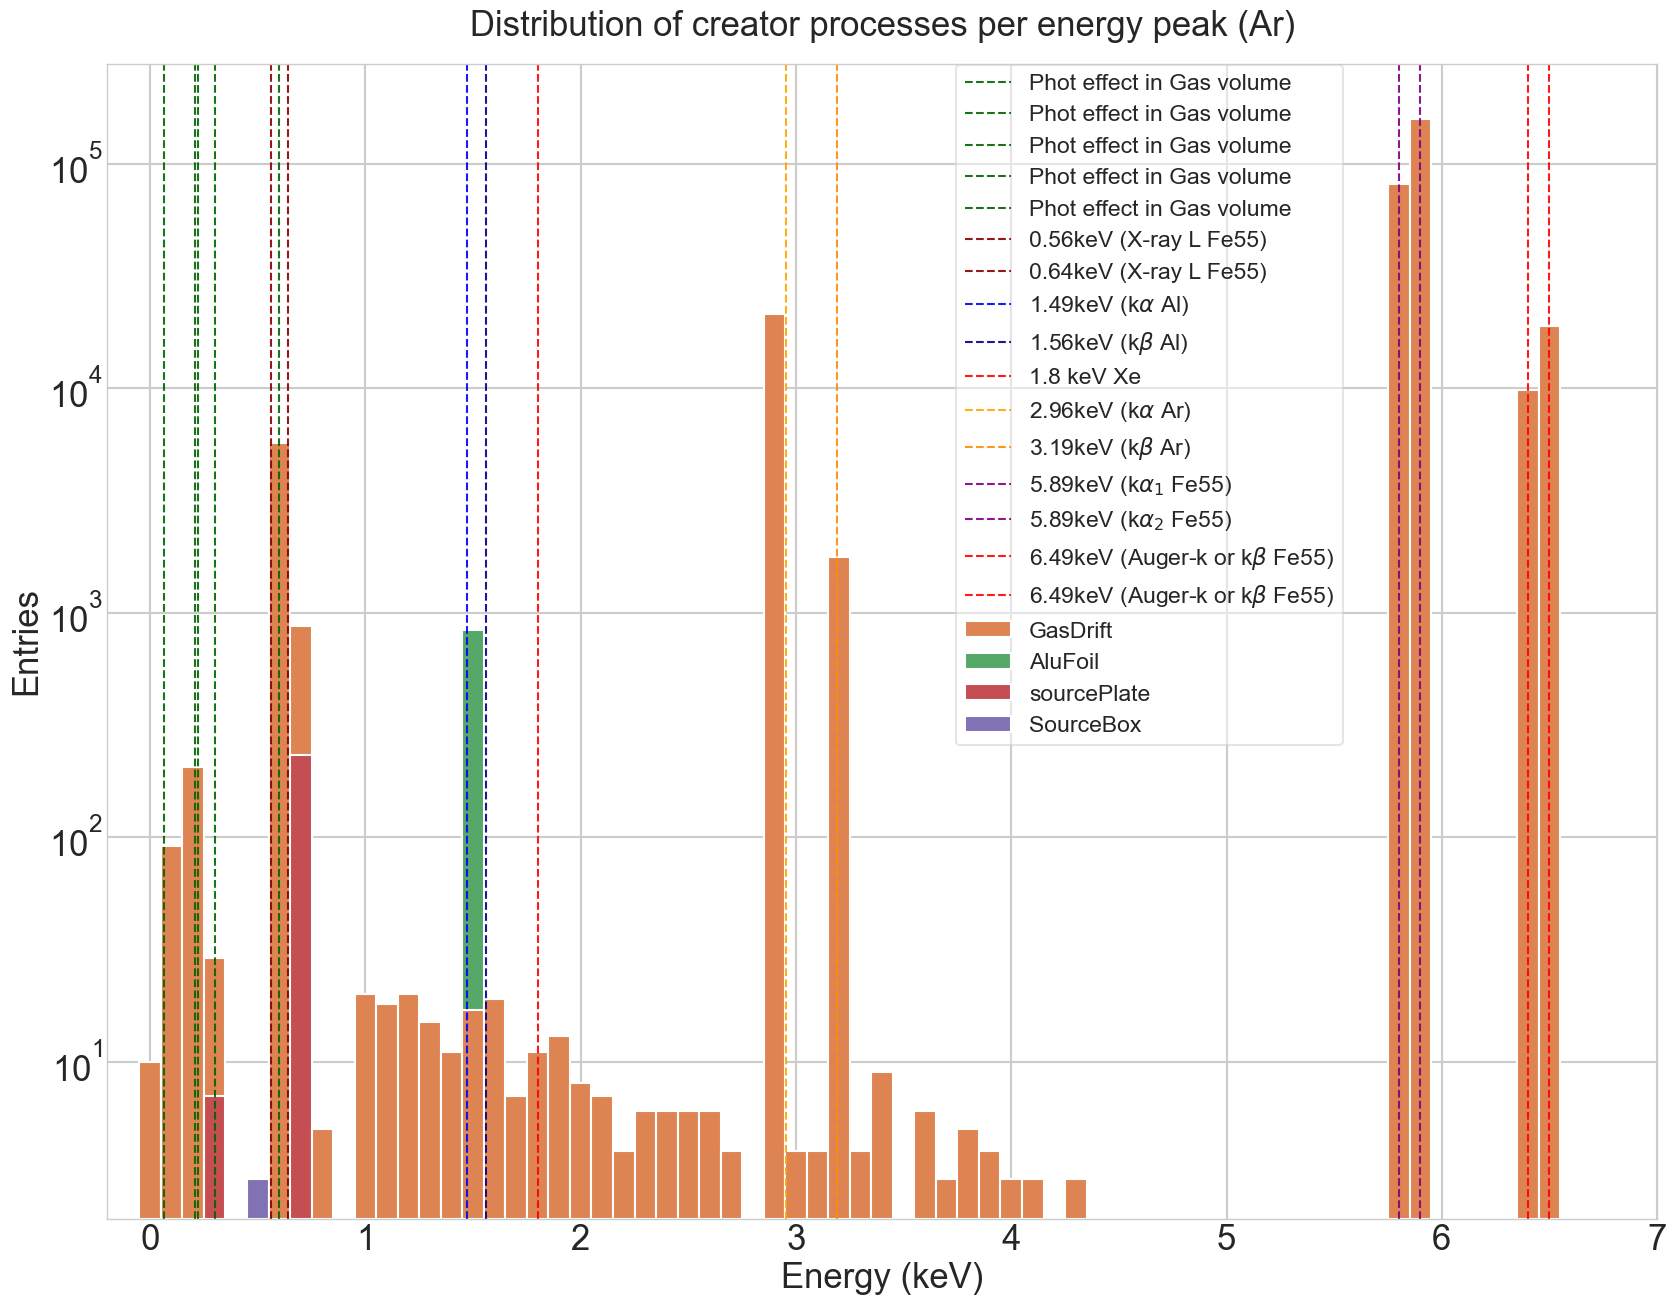

In [608]:
#plot processes per energy peaks Ar

# Largeur des barres
width = 0.1

fig, ax = plt.subplots(figsize=(20,15))

for i in range(len(x)):

    values = values_store[i]
    #print(values)
    #print(x)
    
    for j in range(len(labels_store[i])):
        #print(labels_store)
        if name_study == 'creator_proc':
            if labels_store[i][j] == 'RadioactiveDecay':
                color='C1'
            if labels_store[i][j] == 'phot':
                color='C2'
            if labels_store[i][j] == 'eBrem':
                color='C3'
                
        
        
        if name_study == 'initial_volume':
            if labels_store[i][j] == 'GasDrift':
                color='C1'
            if labels_store[i][j] == 'AluFoil':
                color='C2'
            if labels_store[i][j] == 'sourcePlate':
                color='C3'
            if labels_store[i][j] == 'SourceBox':
                color='C4'

        
        
        ax.bar(x[i], values[j],
               width=width,
               bottom=bottom, color=color)
        
if name_study == 'creator_proc':
    ax.bar(100, 10,bottom=bottom, label='RadioDecay', color='C1')
    ax.bar(100, 10,bottom=bottom,label='PhotElectric', color='C2')
    ax.bar(100, 10,bottom=bottom, label='eBrem', color='C3')

if name_study == 'initial_volume':
    ax.bar(100, 10,bottom=bottom, label='GasDrift', color='C1')
    ax.bar(100, 10,bottom=bottom,label='AluFoil', color='C2')
    ax.bar(100, 10,bottom=bottom, label='sourcePlate', color='C3')
    ax.bar(100, 10,bottom=bottom, label='SourceBox', color='C4')

ax.set_xlim(rangemin-0.2, rangemax)


ax.set_xlabel('Energy (keV)', fontsize=25)
ax.set_ylabel('Entries', fontsize=25)
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=25)
ax.set_yscale('log')
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.set_title(
    "Distribution of creator processes per energy peak (Ar)",
    pad=20 , fontsize=25 # augmente la distance
)

# --- Lignes de référence ---
lines = [
    (0.064,  "Phot effect in Gas volume", "darkgreen"),
    (0.6,  "Phot effect in Gas volume", "darkgreen"),
    (0.21,  "Phot effect in Gas volume", "darkgreen"),
    (0.22,  "Phot effect in Gas volume", "darkgreen"),
    (0.3,  "Phot effect in Gas volume", "darkgreen"),
    (0.56,  "0.56keV (X-ray L Fe55)", "darkred"),
    (0.64,  "0.64keV (X-ray L Fe55)", "darkred"),
    (1.47, "1.49keV (k$\\alpha$ Al)", "blue"),
    (1.56, "1.56keV (k$\\beta$ Al)", "darkblue"),
    (1.8,   "1.8 keV Xe", "red"),
    (2.955, "2.96keV (k$\\alpha$ Ar)", "orange"),
    (3.19,  "3.19keV (k$\\beta$ Ar)", "darkorange"),
    #(4.1,  "4.11keV (L$\\alpha_{1}$ Xe)", "darkorange"),
    (5.8,  "5.89keV (k$\\alpha_{1}$ Fe55)", "purple"),
    (5.9,  "5.89keV (k$\\alpha_{2}$ Fe55)", "purple"),
    (6.4,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    (6.5,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    
]

for energy, label, color in lines:
    ax.axvline(
        energy,
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.9,
        label=label
    )
plt.legend(bbox_to_anchor=(0.54, 0.40), frameon = True, framealpha=0.5)


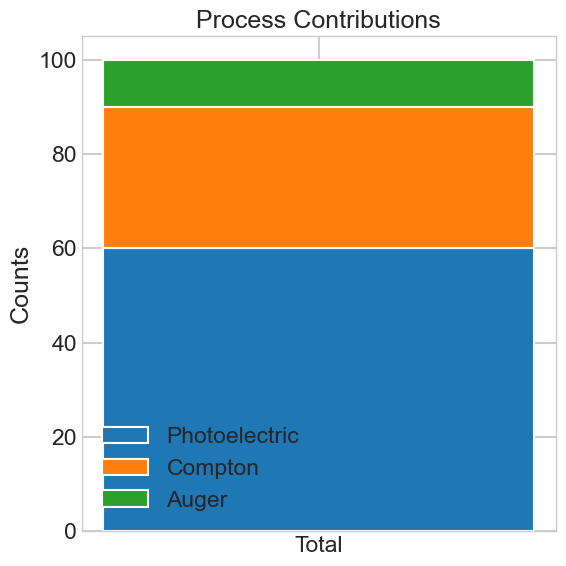

In [299]:
import matplotlib.pyplot as plt
import numpy as np

# Contributions
labels = ["Photoelectric", "Compton", "Auger"]
values = [60, 30, 10]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(6,6))

bottom = 0
for val, label, color in zip(values, labels, colors):
    ax.bar("Total", val, bottom=bottom,
           label=label, color=color)
    bottom += val

ax.set_ylabel("Counts")
ax.set_title("Process Contributions")
ax.legend()

plt.tight_layout()
plt.show()

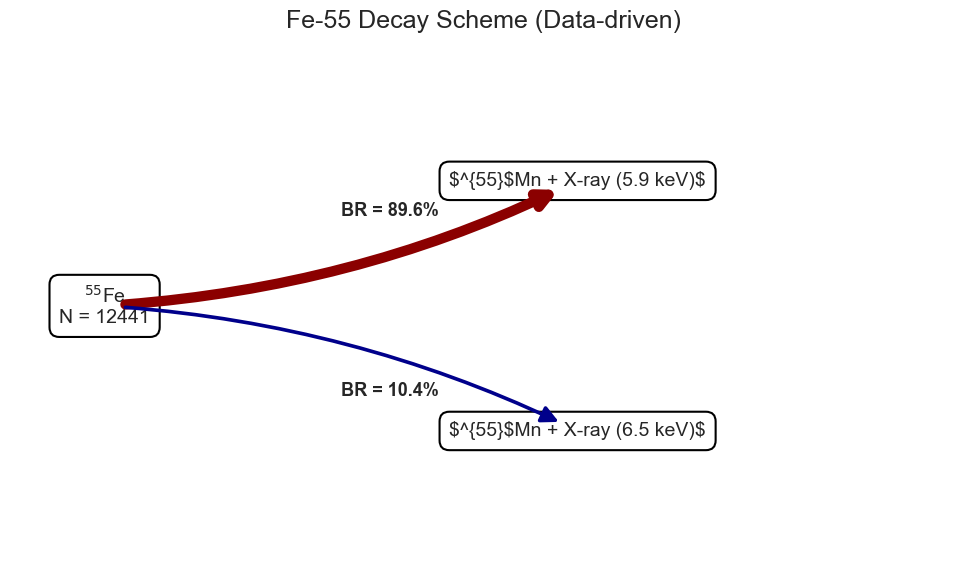

In [30]:
# Load energy kinetic of gammas and do analysis per energy peak

# We load energy kinetic of gammas and we group by decimals
fe55_process = particles[ (particles['particle_name'] == 'gamma')]# & (particles['particle_name'] == 'gamma')]
#fe55_process1 = particles[(particles['creator_proc'] == 'RadioactiveDecay') | (particles['creator_proc'] == 'phot') ]
#fe55_process = fe55_process1[(fe55_process1['particle_name'] == 'gamma')]
#print(fe55_process)
fe55_process['energy_kev'] = fe55_process['kin_energy'] * 1e3
fe55_process["kin_energy_round"] = fe55_process["energy_kev"].round(5)

size_plot = 10
row = 2*len(run_nb)
col = 2
fig, axes = plt.subplots(row, col, figsize=(size_plot * col ,size_plot * row), constrained_layout=True)
axes = axes.flatten()


for i in range(len(ene_study)):

    ene_region = fe55_process[(fe55_process['kin_energy'] >= 5.8/1e3) & (fe55_process['kin_energy'] <= 6/1e3)]




In [158]:
evid = fe55_process[(fe55_process['event_id'] == 12)]
dup = fe55_process[fe55_process['event_id'].duplicated()]

print(fe55_process['event_id'])
print(evid)
print('dup is :', dup)
print('len dup is :', len(dup))

29               2
62               4
159             12
177             14
244             21
             ...  
12364741    999980
12364757    999981
12364887    999993
12364900    999994
12364926    999997
Name: event_id, Length: 298442, dtype: int64
     event_id  particle_id particle_name  primary  mother_id  initial_x  \
159        12            4         gamma        0          1        0.0   

     initial_y  initial_z  initial_t   final_x   final_y    final_z   final_t  \
159        0.0  63.192501   0.001046  0.007434  0.015187  63.189316  0.001104   

    initial_volume final_volume  initial_momentum_x  initial_momentum_y  \
159       GasDrift     GasDrift            0.002531            0.005171   

     initial_momentum_z  final_momentum_x  final_momentum_y  final_momentum_z  \
159           -0.001085               0.0               0.0              -0.0   

     kin_energy    length      creator_proc final_proc  
159    0.005859  0.017206  RadioactiveDecay       phot  
dup 

In [112]:
ev_low = fe55_process[ (fe55_process['kin_energy'] >= 3/1e3) & (fe55_process['kin_energy'] <= 5.7/1e3)]

print(ev_low)

          event_id  particle_id particle_name  primary  mother_id  initial_x  \
101              6           10         gamma        0          6   0.060874   
132              8           10         gamma        0          6  -0.134199   
732             56            8         gamma        0          4  -0.127866   
866             65            9         gamma        0          5  -0.416095   
943             70           10         gamma        0          6   0.083639   
...            ...          ...           ...      ...        ...        ...   
12374519    999767            8         gamma        0          4  -0.012021   
12374555    999769           10         gamma        0          6  -0.268109   
12375797    999871            9         gamma        0          5   0.130890   
12376202    999905           11         gamma        0          6   0.352291   
12376857    999959           10         gamma        0          6   0.159320   

          initial_y  initial_z  initial

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_1811/1611994752.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)


Text(0, 0.5, 'Entries')

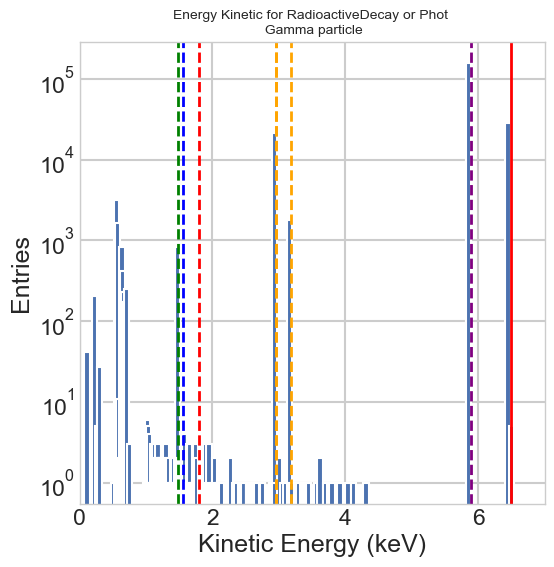

In [526]:
fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)
fe55_process_peak = fe55_process.groupby('kin_energy_round')['kin_energy_round'].agg(['size'])
#print(fe55_process_peak[fe55_process_peak['size']> 1])
#print(fe55_process_peak.reset_index()[['kin_energy_round']])
x = fe55_process_peak.reset_index()['kin_energy_round'].tolist()
x = np.array(x)
#for xval in x:
    #print(f'{xval*1e3:.5f}')
fig, ax = plt.subplots(figsize=(6,6))
ax.bar(x*1e3, fe55_process_peak['size'], width=0.08)

#plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
#plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
#plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
#plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
#plt.axvline(5.89, color='red', linestyle='-', linewidth=2)
plt.axvline(6.49, color='red', linestyle='-', linewidth=2)
ax.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')
ax.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
ax.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
ax.axvline(2.955, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
ax.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')

ax.axvline(3.19, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
#ax.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
ax.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
ax.set_title('Energy Kinetic for RadioactiveDecay or Phot \n Gamma particle', fontsize=10)
ax.set_yscale('log')
ax.set_xlim(0,7)
ax.set_xlabel('Kinetic Energy (keV)')
ax.set_ylabel('Entries')

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_1811/305709401.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


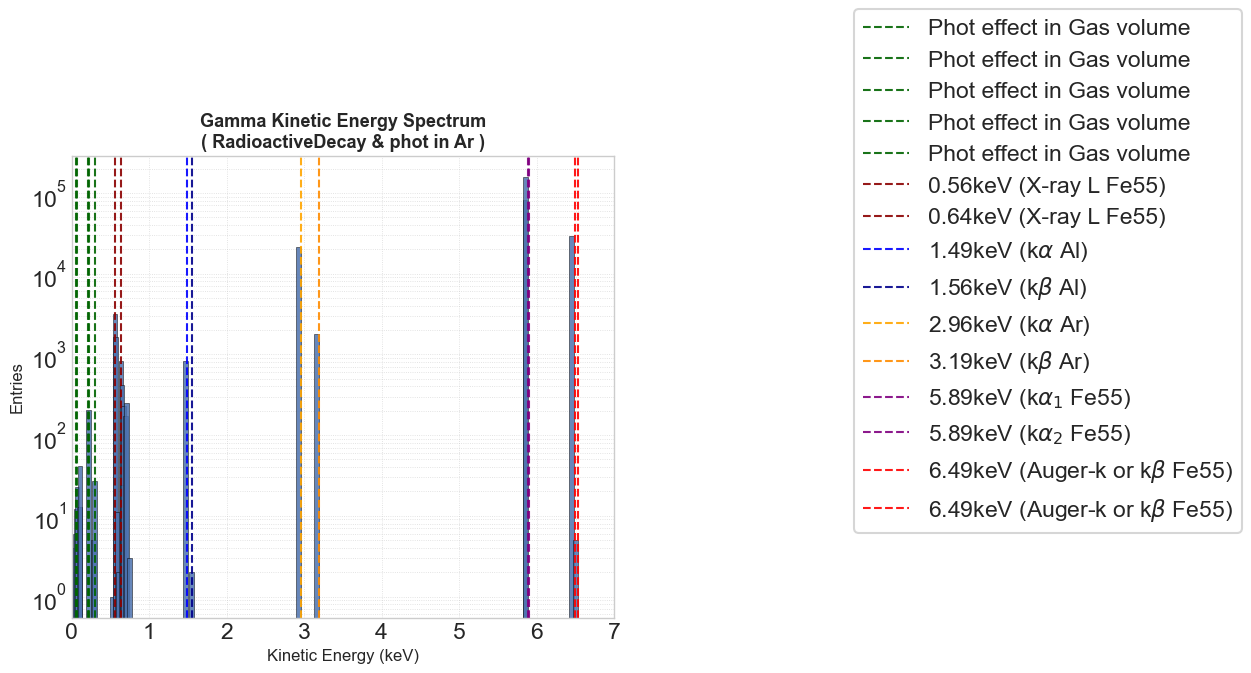

In [497]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize=(7,6))

# Histogramme (barres fines et propres)
ax.bar(
    x * 1e3,
    fe55_process_peak['size'],
    width=0.06,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

# --- Lignes de référence ---
lines = [
    (0.064,  "Phot effect in Gas volume", "darkgreen"),
    (0.06,  "Phot effect in Gas volume", "darkgreen"),
    (0.218,  "Phot effect in Gas volume", "darkgreen"),
    (0.221,  "Phot effect in Gas volume", "darkgreen"),
    (0.299,  "Phot effect in Gas volume", "darkgreen"),
    (0.56,  "0.56keV (X-ray L Fe55)", "darkred"),
    (0.64,  "0.64keV (X-ray L Fe55)", "darkred"),
    (1.486, "1.49keV (k$\\alpha$ Al)", "blue"),
    (1.557, "1.56keV (k$\\beta$ Al)", "darkblue"),
    #(1.8,   "1.8 keV Xe", "red"),
    (2.955, "2.96keV (k$\\alpha$ Ar)", "orange"),
    (3.19,  "3.19keV (k$\\beta$ Ar)", "darkorange"),
    (5.8877,  "5.89keV (k$\\alpha_{1}$ Fe55)", "purple"),
    (5.8988,  "5.89keV (k$\\alpha_{2}$ Fe55)", "purple"),
    (6.49,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    (6.54,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    
]

for energy, label, color in lines:
    ax.axvline(
        energy,
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.9,
        label=label
    )

# --- Mise en forme ---
ax.set_title(
    "Gamma Kinetic Energy Spectrum\n( RadioactiveDecay & phot in Ar )",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Kinetic Energy (keV)", fontsize=12)
ax.set_ylabel("Entries", fontsize=12)

ax.set_yscale("log")
ax.set_xlim(0, 7)

ax.legend(
    loc='center',
    bbox_to_anchor=(1.8, 0.75),  # <-- coordonnées personnalisées
    frameon=True
)

ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_11265/1617626262.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_11265/1617626262.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


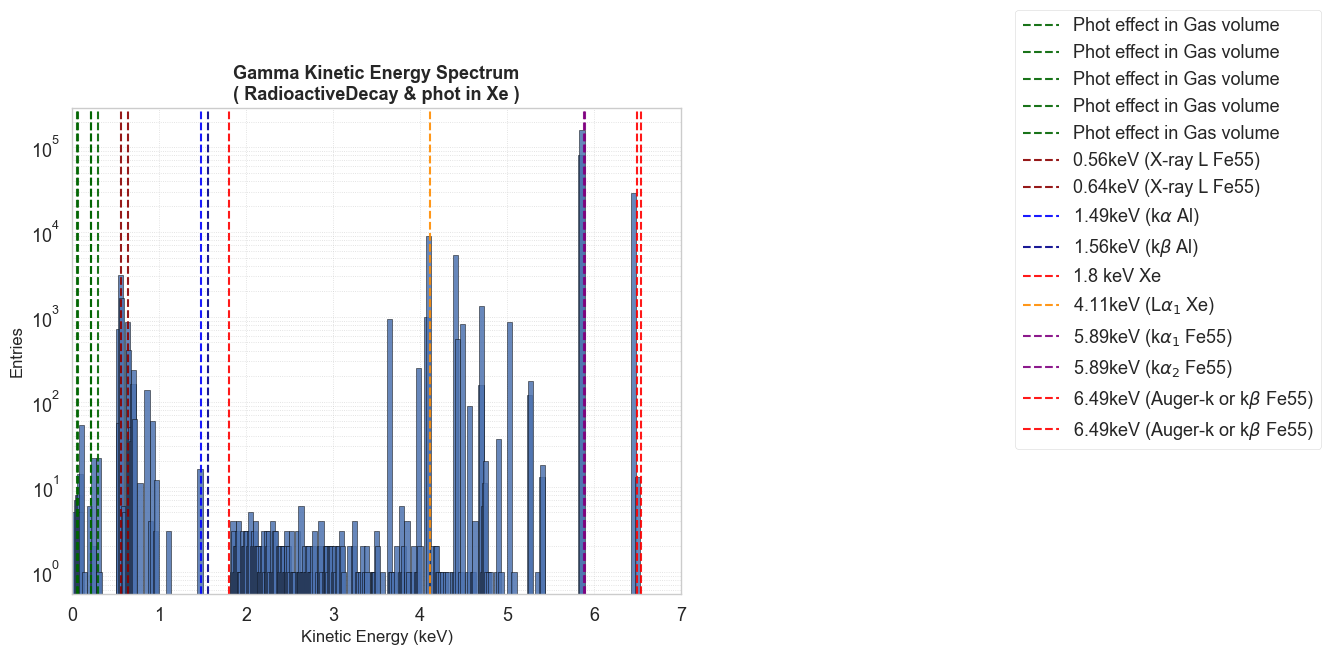

In [127]:
import matplotlib.pyplot as plt
fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)
fe55_process_peak = fe55_process.groupby('kin_energy_round')['kin_energy_round'].agg(['size'])
#print(fe55_process_peak[fe55_process_peak['size']> 1])
#print(fe55_process_peak.reset_index()[['kin_energy_round']])
x = fe55_process_peak.reset_index()['kin_energy_round'].tolist()
x = np.array(x)
plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize=(7,6))

# Histogramme (barres fines et propres)
ax.bar(
    x * 1e3,
    fe55_process_peak['size'],
    width=0.06,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

# --- Lignes de référence ---
lines = [
    (0.064,  "Phot effect in Gas volume", "darkgreen"),
    (0.06,  "Phot effect in Gas volume", "darkgreen"),
    (0.218,  "Phot effect in Gas volume", "darkgreen"),
    (0.221,  "Phot effect in Gas volume", "darkgreen"),
    (0.299,  "Phot effect in Gas volume", "darkgreen"),
    (0.56,  "0.56keV (X-ray L Fe55)", "darkred"),
    (0.64,  "0.64keV (X-ray L Fe55)", "darkred"),
    (1.486, "1.49keV (k$\\alpha$ Al)", "blue"),
    (1.557, "1.56keV (k$\\beta$ Al)", "darkblue"),
    (1.8,   "1.8 keV Xe", "red"),
    #(2.955, "2.96keV (k$\\alpha$ Ar)", "orange"),
    #(3.19,  "3.19keV (k$\\beta$ Ar)", "darkorange"),
    (4.11,  "4.11keV (L$\\alpha_{1}$ Xe)", "darkorange"),
    (5.8877,  "5.89keV (k$\\alpha_{1}$ Fe55)", "purple"),
    (5.8988,  "5.89keV (k$\\alpha_{2}$ Fe55)", "purple"),
    (6.49,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    (6.54,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    
]

for energy, label, color in lines:
    ax.axvline(
        energy,
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.9,
        label=label
    )

# --- Mise en forme ---
ax.set_title(
    "Gamma Kinetic Energy Spectrum\n( RadioactiveDecay & phot in Xe )",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Kinetic Energy (keV)", fontsize=12)
ax.set_ylabel("Entries", fontsize=12)

ax.set_yscale("log")
ax.set_xlim(0, 7)

ax.legend(
    loc='center',
    bbox_to_anchor=(1.8, 0.75),  # <-- coordonnées personnalisées
    frameon=True
)

ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()


In [39]:
import matplotlib.pyplot as plt
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']


Empty DataFrame
Columns: [event_id, particle_id, particle_name, primary, mother_id, initial_x, initial_y, initial_z, initial_t, final_x, final_y, final_z, final_t, initial_volume, final_volume, initial_momentum_x, initial_momentum_y, initial_momentum_z, final_momentum_x, final_momentum_y, final_momentum_z, kin_energy, length, creator_proc, final_proc]
Index: []

[0 rows x 25 columns]


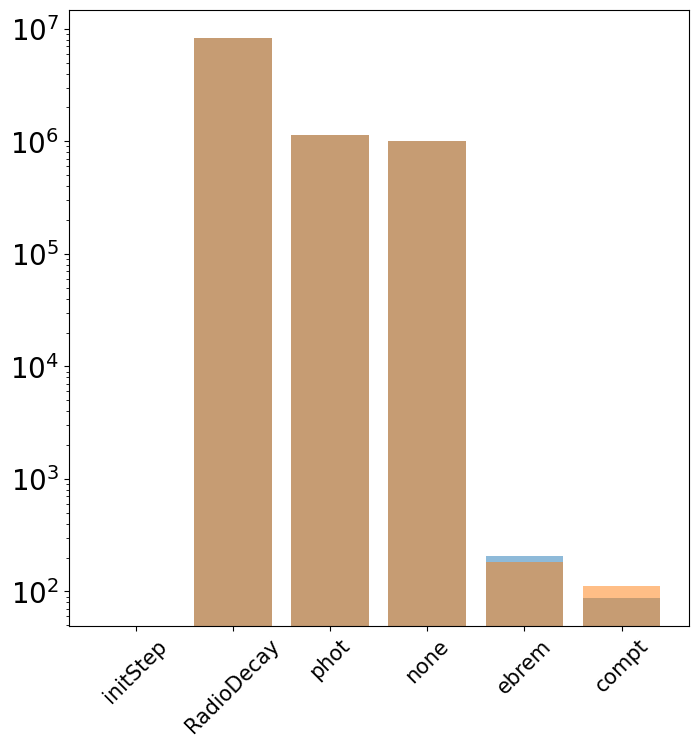

In [76]:
runs = [41, 42]
xlabels = ['initStep', 'RadioDecay', 'phot', 'none', 'ebrem', 'compt']
xaxis = np.arange(0, len(xlabels), 1)
fig, ax = plt.subplots(figsize=(8,8))
for i in range(len(runs)):
    

    filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+str(runs[i])+'.h5'


    hits = pd.read_hdf(filepath_wf, "/MC/hits")
    particles = pd.read_hdf(filepath_wf, "/MC/particles")

    other_proc = particles[(particles['creator_proc'] != 'initStep') 
                           & (particles['creator_proc'] != 'RadioactiveDecay')
                          & (particles['creator_proc'] != 'phot')
                          & (particles['creator_proc'] != 'none')
                          & (particles['creator_proc'] != 'eBrem')
                          & (particles['creator_proc'] != 'compt')]

    initStep = particles[(particles['creator_proc'] == 'initStep')]
    RadioDecay = particles[(particles['creator_proc'] == 'RadioactiveDecay')]
    phot = particles[(particles['creator_proc'] == 'phot')]
    none = particles[(particles['creator_proc'] == 'none')]
    ebrem = particles[(particles['creator_proc'] == 'eBrem')]
    compt = particles[(particles['creator_proc'] == 'compt')]
    
    
    
    yval = [len(initStep), len(RadioDecay), len(phot), len(none), len(ebrem), len(compt)]
    ax.bar(xaxis, yval, alpha=0.5)
    
ax.set_xticks(xaxis)
ax.set_xticklabels(xlabels, fontsize=15, rotation=45)
ax.set_yscale('log')
print(other_proc.head(10))



0
Empty DataFrame
Columns: [event_id, particle_id, particle_name, primary, mother_id, initial_x, initial_y, initial_z, initial_t, final_x, final_y, final_z, final_t, initial_volume, final_volume, initial_momentum_x, initial_momentum_y, initial_momentum_z, final_momentum_x, final_momentum_y, final_momentum_z, kin_energy, length, creator_proc, final_proc]
Index: []

[0 rows x 25 columns]


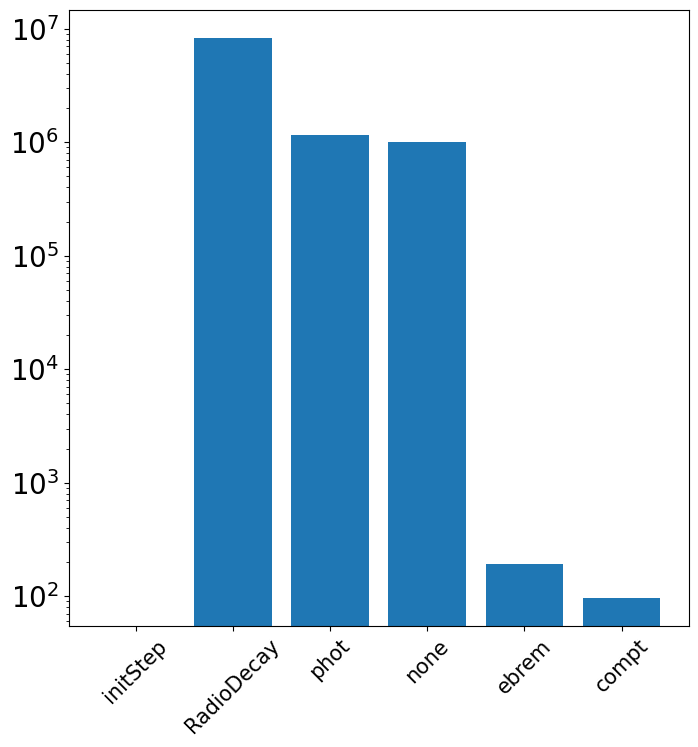

In [43]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
energy_study = particles[(particles['kin_energy'] > 4/1e3) & (particles['kin_energy'] < 4.3/1e3)]

energy_study['energy_kev'] = energy_study['kin_energy'] * 1e3

#energy_study.head(100)

particle_study = particles[(particles['particle_id'] == 1) & (particles['event_id'] == 1)]

particle_study.head(100)

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_58687/3062737824.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  energy_study['energy_kev'] = energy_study['kin_energy'] * 1e3


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,final_y,final_z,final_t,initial_volume,final_volume,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
18,1,1,Fe55,1,0,0.0,0.0,67.692497,0.0,0.0,0.0,67.692497,0.001881,GasDrift,GasDrift,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,RadioactiveDecay


In [37]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
event_study = hits[(hits['event_id'] == 55)]


event_study.head(100)

,event_id,x,y,z,time,energy,label,particle_id,hit_id
1151,55,-1.166856e-04,-0.000044,67.692589,0.114898,4.930334e-07,DRIFT,9,0
1152,55,-2.405930e-03,0.000265,67.697495,0.000355,7.049448e-04,DRIFT,8,0
1153,55,-2.589484e-03,0.002085,67.700592,0.000446,5.487446e-05,DRIFT,8,1
1154,55,3.870711e-04,0.004516,67.702179,0.000552,1.424951e-04,DRIFT,8,2
1155,55,1.896611e-03,0.008341,67.702324,0.000658,3.215998e-05,DRIFT,8,3
1156,55,2.769246e-03,0.015219,67.704361,0.000846,3.022989e-03,DRIFT,8,4
1157,55,3.454137e-03,0.013670,67.703667,0.001036,2.132067e-05,DRIFT,8,5
1158,55,3.844129e-03,0.013348,67.703247,0.001067,5.007185e-05,DRIFT,8,6
1159,55,4.580701e-03,0.012740,67.702461,0.001128,5.724721e-05,DRIFT,8,7
1160,55,4.569404e-03,0.012595,67.702324,0.001138,2.999254e-04,DRIFT,8,8


In [172]:
gamma = particles[(particles['particle_name'] == 'gamma')]
gamma_keV = gamma['kin_energy'] * 1000
gamma.loc[(gamma['kin_energy'] > 0/1000) & (gamma['kin_energy'] < 1/1000)]


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
1910,147,5,gamma,0,1,0.00000,0.000000,67.692497,0.001107,-0.022833,...,-0.000107,-0.000354,-0.000420,-0.0,-0.0,-0.0,0.000560,0.119020,RadioactiveDecay,phot
2612,204,8,gamma,0,1,0.00000,0.000000,67.692497,0.000232,0.007025,...,0.000174,0.000642,-0.000236,0.0,0.0,-0.0,0.000706,0.028430,RadioactiveDecay,phot
2932,232,6,gamma,0,1,0.00000,0.000000,67.692497,0.000905,0.036305,...,0.000517,-0.000388,-0.000079,0.0,-0.0,-0.0,0.000651,0.045753,RadioactiveDecay,phot
12694,1023,5,gamma,0,1,0.00000,0.000000,67.692497,0.000657,0.126325,...,0.000507,-0.000234,0.000036,0.0,-0.0,0.0,0.000560,0.139425,RadioactiveDecay,phot
15601,1261,10,gamma,0,5,0.03142,0.033324,67.630226,0.001558,0.073730,...,0.000124,0.000193,-0.000477,0.0,0.0,-0.0,0.000530,0.180160,phot,phot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12364371,999330,5,gamma,0,1,0.00000,0.000000,67.692497,0.001740,-0.029232,...,-0.000175,-0.000459,-0.000289,-0.0,-0.0,-0.0,0.000570,0.095015,RadioactiveDecay,phot
12368609,999667,9,gamma,0,1,0.00000,0.000000,67.692497,0.000231,0.034182,...,0.000416,-0.000374,-0.000004,0.0,-0.0,-0.0,0.000560,0.046001,RadioactiveDecay,phot
12370131,999793,7,gamma,0,1,0.00000,0.000000,67.692497,0.003652,-0.105946,...,-0.000152,-0.000288,0.000468,-0.0,-0.0,0.0,0.000570,0.397083,RadioactiveDecay,phot
12371319,999887,8,gamma,0,4,0.13814,0.166830,67.813370,0.001132,0.194651,...,0.000403,-0.000580,-0.000489,0.0,-0.0,-0.0,0.000859,0.120487,phot,phot


In [173]:
gamma_filter = gamma[(gamma['kin_energy'] > 2/1000) & (gamma['kin_energy'] < 4/1000)]
#gamma_filter.loc[(gamma_filter['creator_proc'] == 'RadioactiveDecay')]
gamma_filter.loc[(gamma_filter['particle_name'] == 'gamma')]

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
2152,168,9,gamma,0,5,0.005052,-0.005308,67.676781,0.000069,-0.116720,...,-0.000255,0.001895,-0.003113,-0.0,0.0,-0.0,0.003653,1.745378,phot,phot
17054,1372,8,gamma,0,4,0.944093,-0.655924,67.627449,0.005126,1.091838,...,0.000832,-0.002384,-0.002639,0.0,-0.0,-0.0,0.003653,0.648926,phot,phot
17614,1413,8,gamma,0,4,-0.034122,0.041094,68.145134,0.002195,-0.437077,...,-0.001275,-0.003336,0.000766,-0.0,-0.0,0.0,0.003653,1.154326,phot,phot
26466,2128,8,gamma,0,4,-0.181549,0.187733,67.225449,0.001955,-0.098622,...,0.003255,-0.000764,0.001471,0.0,-0.0,0.0,0.003653,0.093064,phot,phot
30268,2439,9,gamma,0,5,-0.130891,0.055283,67.705811,0.003967,0.430176,...,0.001397,-0.000391,-0.003352,0.0,-0.0,-0.0,0.003653,1.466546,phot,phot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12336500,997025,10,gamma,0,6,-0.166010,2.583333,67.878563,0.009567,-0.160413,...,0.003158,0.000715,0.001690,0.0,0.0,0.0,0.003653,0.006473,phot,phot
12337795,997134,63,gamma,0,9,0.006007,0.004001,67.685493,0.000770,0.513355,...,0.001531,0.002332,-0.001913,0.0,0.0,-0.0,0.003383,1.120766,eBrem,phot
12338246,997168,11,gamma,0,7,0.140541,-0.006918,67.583397,0.003974,-0.073055,...,-0.000723,0.002114,-0.003296,-0.0,0.0,-0.0,0.003982,1.177010,phot,phot
12341242,997404,12,gamma,0,8,0.005760,-0.281419,67.767487,0.001342,0.050505,...,0.000272,0.002379,0.002758,0.0,0.0,0.0,0.003653,0.600564,phot,phot


353
269963
The ratio between the 5.9keV and the 1.4keV peaks is :  764.7677053824362


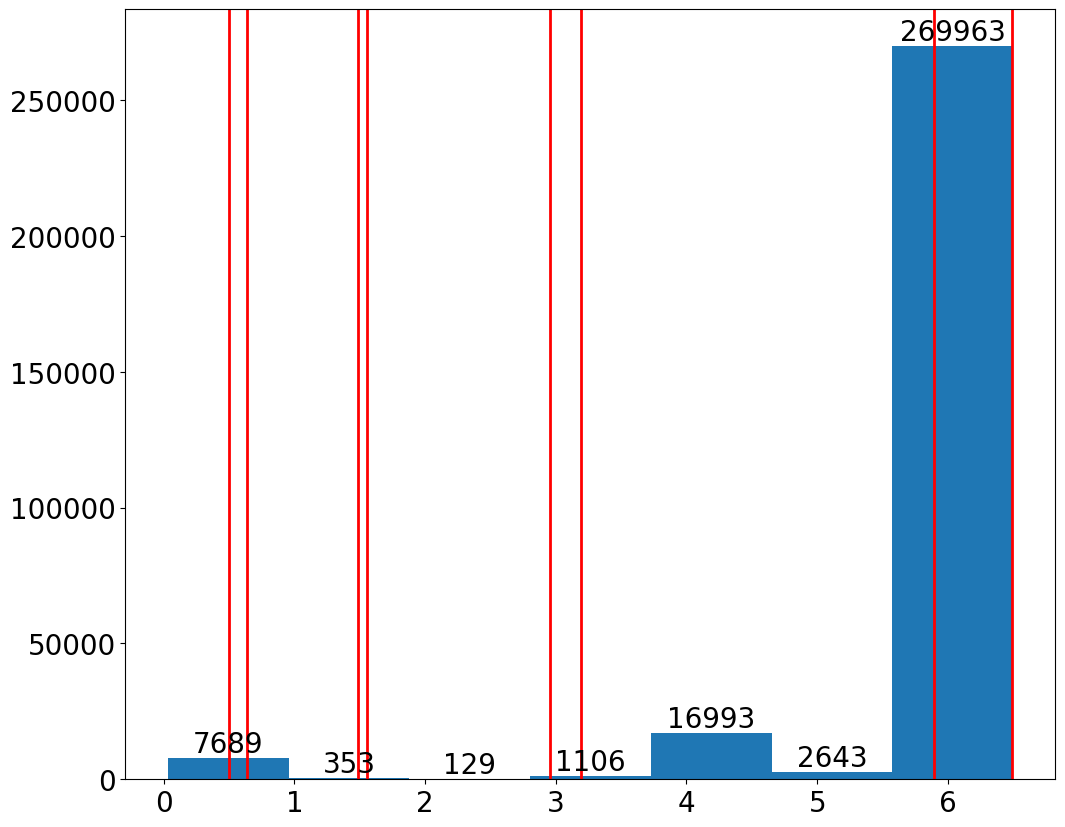

In [174]:
counts, bins, patches = plt.hist(gamma_keV, bins = 7)
plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
plt.axvline(5.89, color='red', linestyle='-', linewidth=2)
plt.axvline(6.49, color='red', linestyle='-', linewidth=2)

count_store = []

for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    bin_center = (bin_left + bin_right) / 2
    plt.text(bin_center, count, str(int(count)), ha='center', va='bottom', fontsize=20)
    count_store.append(count)
print(str(int(count_store[1])))
print(str(int(count_store[6])))
print("The ratio between the 5.9keV and the 1.4keV peaks is : ", count_store[6]/count_store[1])

#plt.yscale('log')

In [21]:
hits.loc[(hits['event_id'] == 2)]





,event_id,x,y,z,time,energy,label,particle_id,hit_id
50,2,-0.000123,0.000175,67.693016,0.426773,4.930334e-07,DRIFT,6,0
51,2,0.003296,-0.001446,67.695503,0.001284,5.784741e-04,DRIFT,4,0
52,2,-0.000029,0.000101,67.692596,0.000993,3.841456e-05,DRIFT,3,0
53,2,0.000015,-0.000128,67.692451,0.000993,3.540312e-05,DRIFT,2,0


# start of analysis

In [102]:

filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/xenon/GaP_Fe55_Xenon_Alu_4.0.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_100000.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_5.h5'
#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_100.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_45.h5'



#for i in range(len(pressure)):
# filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/alu_6.5bar_294kel.h5'

#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/xenon/GaP_Fe55_Xenon_Alu_'+str(pressure[i])+'.h5'
#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/argon/1000000evts_Argon/GaP_Fe55_Argon_Alu_'+str(pressure[i])+'.h5'
print(filepath_wf)
hits = pd.read_hdf(filepath_wf, "/MC/hits")
particles = pd.read_hdf(filepath_wf, "/MC/particles")

#hits.to_csv("/Users/ldonneger/Desktop/hits.txt", sep="\t", index=False)
#particles.to_csv("/Users/ldonneger/Desktop/particles.txt", sep="\t", index=False)




/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_45.h5


In [85]:
pd.set_option('display.max_columns', 500)
alu = particles[(particles['initial_volume'] == 'AluminumFoil') & (particles['particle_name'] == 'gamma')]
print(alu)

        event_id  particle_id particle_name  primary  mother_id  initial_x  \
8863         841           13         gamma        0          9  -0.834541   
21072       2003            9         gamma        0          5   2.734166   
72167       6873           10         gamma        0          6  -3.099128   
79204       7539           10         gamma        0          6   4.700519   
92014       8746           10         gamma        0          6   2.463961   
94206       8958           17         gamma        0         10  -0.693193   
103307      9822           11         gamma        0          7  -1.295018   

        initial_y  initial_z  initial_t   final_x   final_y   final_z  \
8863     3.637340   1.415162   0.015203 -0.833907  3.638260  1.412166   
21072    2.348447   1.411731   0.013822  2.750506  2.351436  1.415891   
72167    2.695980   1.415018   0.015468 -3.098076  2.698519  1.409705   
79204    0.689131   1.410713   0.016859  4.681624  0.707671  1.410315   
92014   -0

In [103]:
event_id = hits['event_id']
event_max = event_id.max()
print(event_max)


999999


In [104]:

%%time
#sum energy dep event by event
#pressure = np.arange(2, 8.5, 0.5)


edep_store = []
edep = hits[(hits['label'] == 'DRIFT')]
edep['energy_kev'] = edep['energy'] * 1e3

for j in range(0, event_max):
#for j in range(0, 1000):
 
    edep2 = edep[(edep['event_id'] == j)]
    
    edep_store.append(edep2.energy_kev.sum())


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/magics/execution.py", line 1325, in time
    exec(code, glob, local_ns)
  File "<timed exec>", line 12, in <module>
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/pandas/core/frame.py", line 3449, in __getitem__
    return self._getitem_bool_array(key)
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/pandas/core/frame.py", line 3503, in _getitem_bool_array
    indexer = key.nonzero()[0]
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 2105, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/ultratb.py", line 1396, in structured_

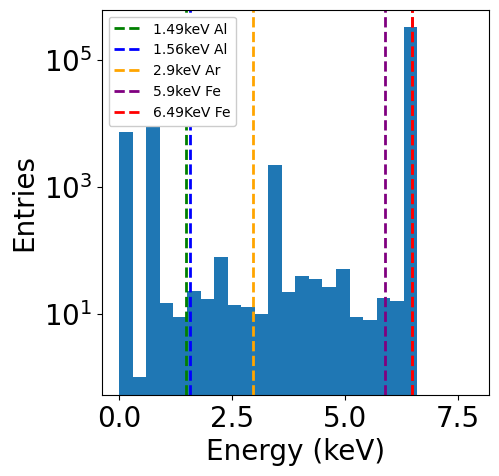

In [106]:
edep_store = np.array(edep_store)
bins = np.arange(0, 8, 0.3)
#mask = (edep_store >= 0.5)
plt.figure(figsize=(5,5))
counts, bins, patches = plt.hist(edep_store, bins = bins, density=False)
mask_59 = (edep_store >= 5) & (edep_store <= 6)
mask_59 = (edep_store >= 5) & (edep_store <= 6)
#plt.xlim(0,7)
#plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
#plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
#plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
#plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
#plt.axvline(5.89, color='red', linestyle='-', linewidth=2)
plt.axvline(6.49, color='red', linestyle='--', linewidth=2)
#plt.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')


plt.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
plt.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
plt.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
#plt.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
plt.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
plt.axvline(6.49, color='red', linestyle='--', linewidth=2, label='6.49KeV Fe')
plt.yscale('log')
plt.ylabel('Entries')
plt.xlabel('Energy (keV)')
plt.legend(loc='upper left', fontsize=10, framealpha=1)
plt.show()

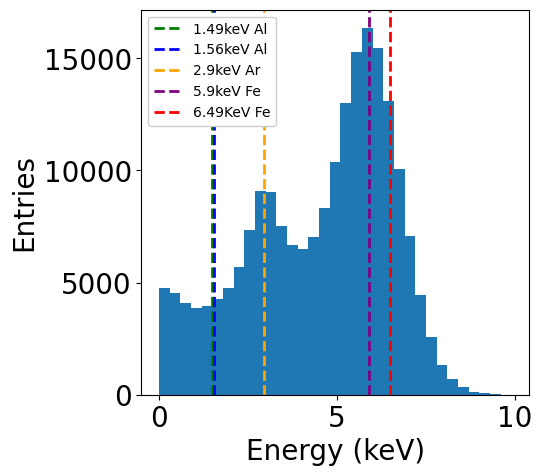

In [17]:
energy = 5.9

sigma_init = 0.15
resolution = []
edep_store1 = edep_store
edep_store1 = np.array(edep_store1)

for i in range(len(edep_store1)):
    sigma_smear = np.sqrt(edep_store[i]/energy)*sigma_init
    smear59 = np.random.normal(1, sigma_smear, 1)
    edep_store1[i] = edep_store1[i] * smear59

bins = np.arange(0, 10, 0.3)
#mask = (edep_store >= 0.5)
plt.figure(figsize=(5,5))
counts, bins, patches = plt.hist(edep_store1, bins = bins, density=False)
#plt.xlim(0,7)
#plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
#plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
#plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
#plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
#plt.axvline(5.89, color='red', linestyle='-', linewidth=2)

#plt.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')
plt.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
plt.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
plt.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
#plt.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
plt.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
plt.axvline(6.49, color='red', linestyle='--', linewidth=2, label='6.49KeV Fe')
#plt.yscale('log')
plt.ylabel('Entries')
plt.xlabel('Energy (keV)')
plt.legend(loc='upper left', fontsize=10, framealpha=1)
plt.show()

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_37.h5
130829
33
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_38.h5
124875
33


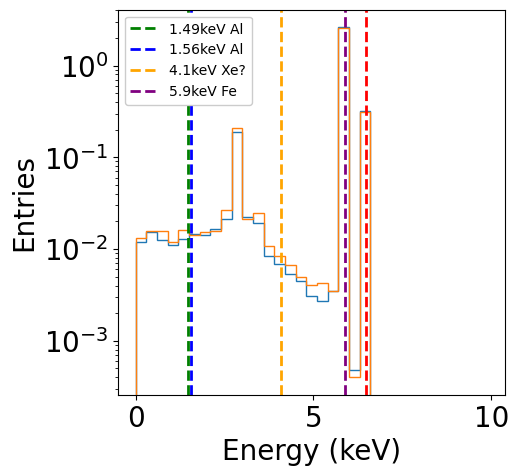

     count37   count38      diff
0   0.011975  0.013106  0.001132
1   0.015516  0.015536  0.000019
2   0.012663  0.015722  0.003060
3   0.011134  0.011985  0.000851
4   0.013020  0.015936  0.002916
5   0.014574  0.014201  0.000373
6   0.014268  0.015509  0.001241
7   0.016332  0.015722  0.000609
8   0.021427  0.026426  0.004999
9   0.189586  0.209863  0.020277
10  0.022115  0.021088  0.001028
11  0.019262  0.024878  0.005616
12  0.008484  0.010918  0.002433
13  0.006854  0.008328  0.001475
14  0.005300  0.006700  0.001400
15  0.004459  0.004912  0.000453
16  0.003057  0.004057  0.001000
17  0.002726  0.004244  0.001518
18  0.003491  0.003524  0.000033
19  2.617259  2.579353  0.037906
20  0.000484  0.000400  0.000084
21  0.319348  0.310924  0.008424
22  0.000000  0.000000  0.000000
23  0.000000  0.000000  0.000000
24  0.000000  0.000000  0.000000
25  0.000000  0.000000  0.000000
26  0.000000  0.000000  0.000000
27  0.000000  0.000000  0.000000
28  0.000000  0.000000  0.000000
29  0.0000

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_6819/657888291.py:58: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-5, 5)


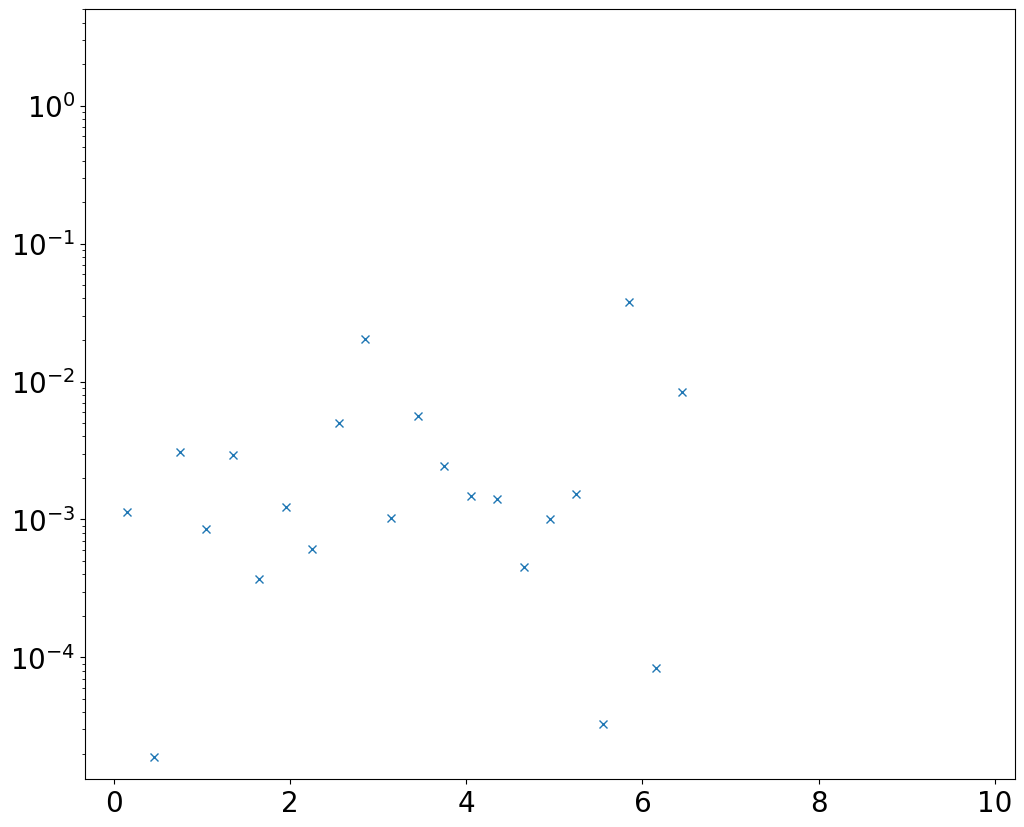

In [22]:
run_nb = [37, 38]
plt.figure(figsize=(5,5))
count_diff = pd.DataFrame({})
for i in range(len(run_nb)):
    
    filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+str(run_nb[i])+'.h5'
    print(filepath_wf)
    hits = pd.read_hdf(filepath_wf, "/MC/hits")
    particles = pd.read_hdf(filepath_wf, "/MC/particles")

    event_id = hits['event_id']
    event_max = event_id.max()
    print(event_max)

    #%%time
    #sum energy dep event by event
    #pressure = np.arange(2, 8.5, 0.5)


    edep_store = []
    edep = hits[(hits['label'] == 'DRIFT')]
    edep['energy_kev'] = edep['energy'] * 1e3

    for j in range(0, event_max):
    #for j in range(0, 1000):

        edep2 = edep[(edep['event_id'] == j)]

        edep_store.append(edep2.energy_kev.sum())

    edep_store = np.array(edep_store)
    bins = np.arange(0, 10, 0.3)
    #mask = (edep_store >= 0.5)
    
    
    counts, bins, patches = plt.hist(edep_store, bins = bins, density=True, histtype='step')
    print(len(counts))
    count_diff['count'+str(run_nb[i])] = counts
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

plt.axvline(6.49, color='red', linestyle='--', linewidth=2)
#plt.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')
plt.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
plt.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
#plt.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
plt.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
plt.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
plt.yscale('log')
plt.ylabel('Entries')
plt.xlabel('Energy (keV)')
plt.legend(loc='upper left', fontsize=10, framealpha=1)
plt.show() 

count_diff['diff'] = np.abs(count_diff['count'+str(run_nb[0])] - count_diff['count'+str(run_nb[1])])

plt.errorbar(bin_centers, count_diff['diff'], marker='x', linestyle='')
plt.yscale('log')
plt.ylim(-5, 5)
plt.axhline(0, color='red', linewidth=2)
#plt.xlim(0, 1e-2)
print(count_diff)
    

# Check MC waveforms (Adelma)

In [31]:
pmt_sample_size = 0.1 # in µs

In [221]:
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_3/simGanESS/results/elfield/'
#main_path   = '/home/investigator/GanEss//GanESS_G4Sim/simGanESS/results/100/'
run_nb = '32'
#filepath_wf = main_path + filename_wf
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_1_adelma.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_2_adelma.h5'
#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_10000_adelma.h5'
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+run_nb+'_adelma.h5'

!ptdump $filepath_wf
#!ptdump -vd $filepath_wf:/pmtrd
#!ptdump -vd $filepath_wf:/Filters/detected_events
#!ptdump -vd $filepath_wf:/Filters/signal
#!ptdump -vd $filepath_wf:/MC
#!ptdump -vd $filepath_wf:/MC/event_mapping
#!ptdump -vd $filepath_wf:/MC/hits
#!ptdump -vd $filepath_wf:/MC/particles
#!ptdump -vd $filepath_wf:/MC/sns_positions
#!ptdump -vd $filepath_wf:/MC/sns_response
#!ptdump -vd $filepath_wf:/Run/eventMap
#!ptdump -vd $filepath_wf:/Run/events
#!ptdump -vd $filepath_wf:/Run/runInfo
#!ptdump -v $filepath_wf:/config/adelma
#!ptdump -dv $filepath_wf:/pmtrd

   
    
    
    
#!ptdump -vd $filepath_wf:/MC/particles
    

/ (RootGroup) ''
/pmtrd (EArray(7791, 7, 1400)shuffle, zlib(4)) ''
/Filters (Group) ''
/Filters/detected_events (Table(7793,)shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/signal (Table(7791,)shuffle, zlib(4)) 'Event has passed filter flag'
/MC (Group) ''
/MC/configuration (Table(34,)shuffle, zlib(4)) ''
/MC/event_mapping (Table(7791,)shuffle, zlib(4)) ''
/MC/hits (Table(143276,)shuffle, zlib(4)) ''
/MC/particles (Table(146067,)shuffle, zlib(4)) ''
/MC/sns_positions (Table(7,)shuffle, zlib(4)) ''
/MC/sns_response (Table(2622568,)shuffle, zlib(4)) ''
/Run (Group) ''
/Run/eventMap (Table(7791,)shuffle, zlib(4)) 'event & nexus evt for each index'
/Run/events (Table(7791,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(7791,)shuffle, zlib(4)) 'run info table'
/config (Group) ''
/config/adelma (Table(12,)shuffle, zlib(4)) 'configuration for adelma'


[0 1 2 3 4 5]
7791
[10.67062782 26.1313725   1.24558709]
popt[0]  10.670627822118904 popt[2]  1.2455870875280255


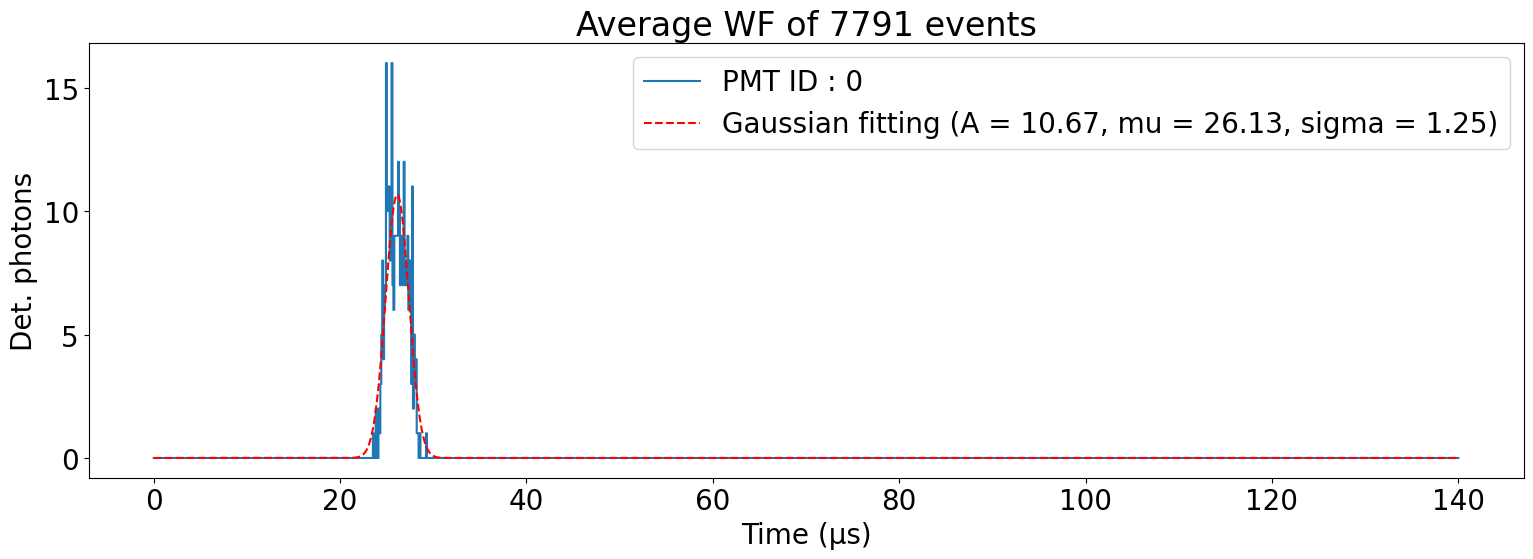

[10.99707799 26.37499345 -1.27530341]
popt[0]  10.99707799260781 popt[2]  -1.2753034074954057


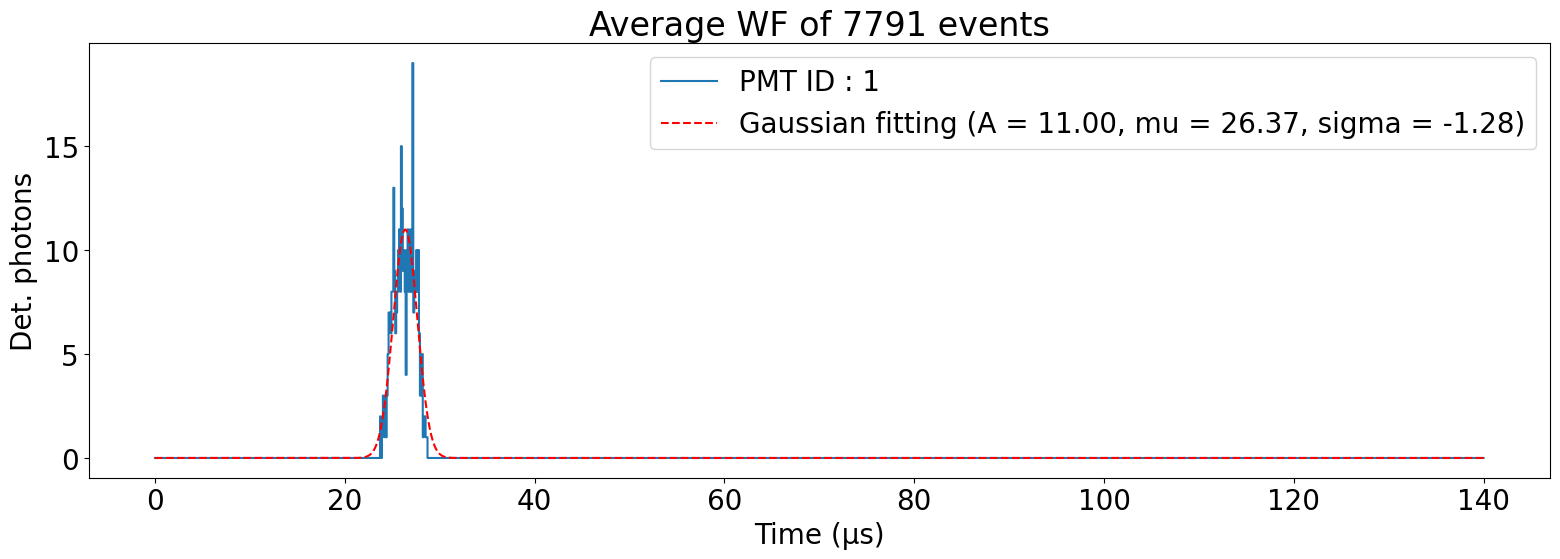

[11.13507599 26.4375046  -1.22935737]
popt[0]  11.135075993565742 popt[2]  -1.2293573704688445


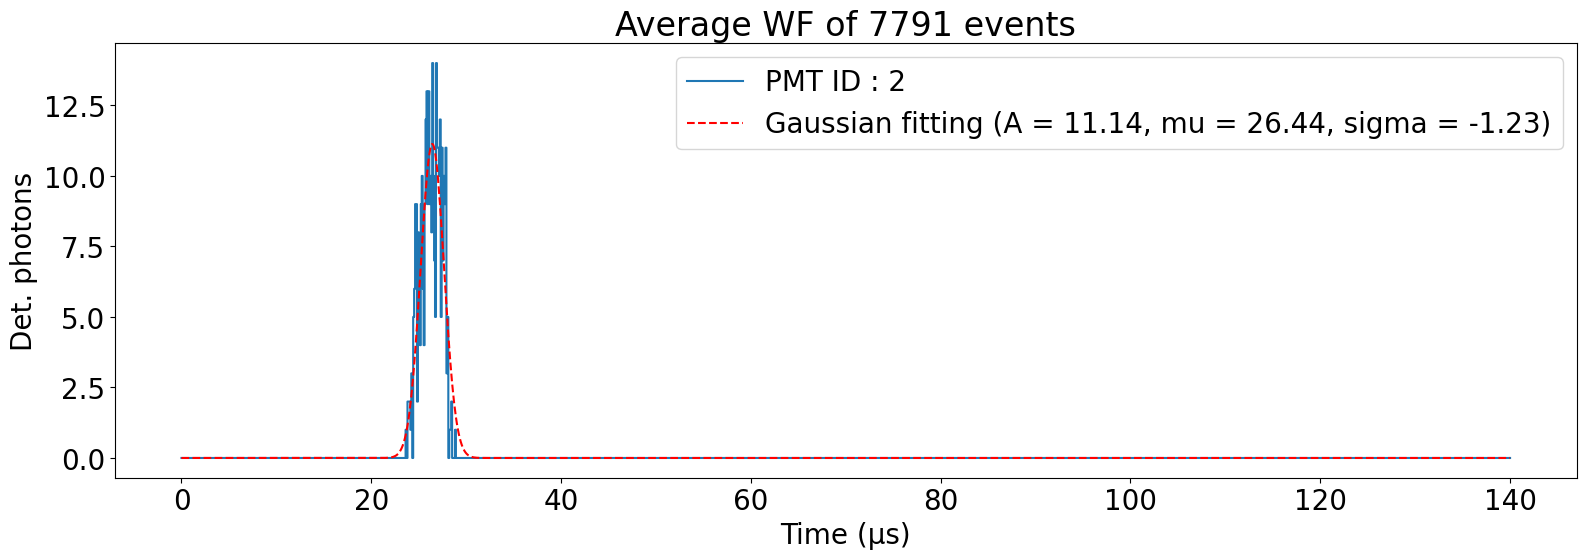

[41.10947691 26.58681192  1.31093678]
popt[0]  41.10947691398179 popt[2]  1.3109367812526238


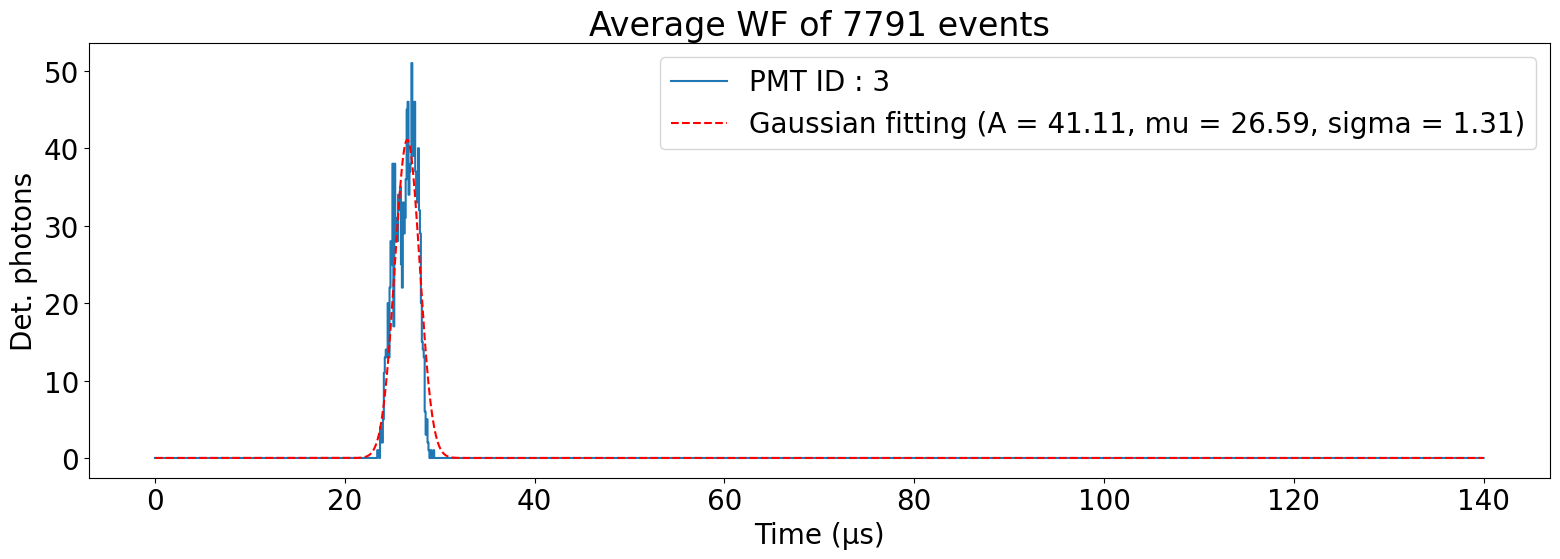

[10.28513062 26.34200303 -1.34750196]
popt[0]  10.285130624945971 popt[2]  -1.3475019577578868


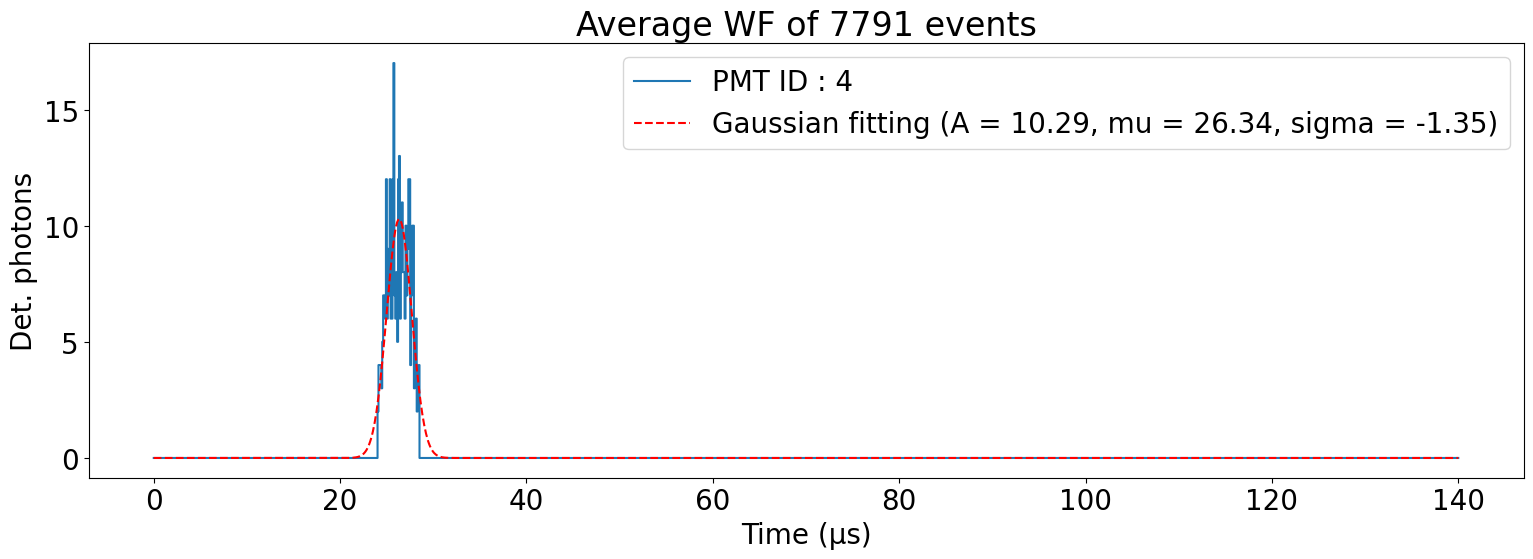

[10.18810706 26.31015737  1.35708104]
popt[0]  10.188107059132712 popt[2]  1.35708103631837


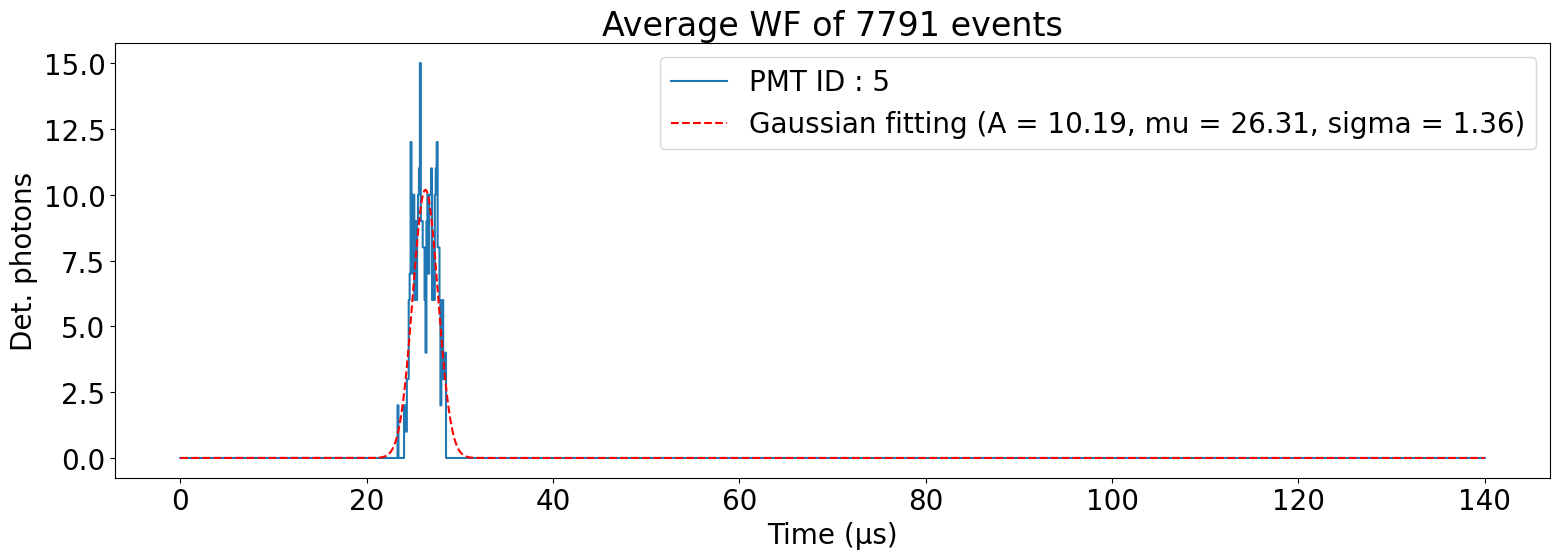

In [222]:
def gauss(x,amp,mu,sigma):
    return amp*np.exp(-(x-mu)**2/(2*sigma**2))
tab = []
inf = 0
pmt_rwf = []
pmt_id = np.arange(0,6)
pi = np.pi
charges = []
print(pmt_id)
with tb.open_file(filepath_wf, 'r') as h5in:
    tab[:] = h5in.root.pmtrd
    print(len(tab))
    sup = len(tab)
    for pmt in pmt_id:
        #print(pmt)
        pmt_rwf_tot = []
        moy = []
        plt.figure(figsize=(16, 6))
        for j in range(inf,sup):
            pmt_rwf[:] = h5in.root.pmtrd[j][pmt]#[0] # WF seen in each PMTs
            t = np.linspace(0, len(pmt_rwf)*pmt_sample_size, len(pmt_rwf))
            pmt_rwf_tot.append(pmt_rwf)
            #print(pmt_rwf[900])
            #print(pmt_rwf_tot)
            #print(t)
            #plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, label='PMT ID : ')
            #plt.legend()
            #plt.xlabel('Time (µs)')
            #plt.ylabel('Det. photons')
            #plt.title('Event number : '+str(j))
            #plt.tight_layout()
            #print(f'PMT ID Number : {i}')

        moy = [sum(colonne)/(sup - inf) for colonne in zip(*pmt_rwf_tot)]
        #print(moy[900])
        plt.plot(t, moy, drawstyle='steps', lw=1.5, label='PMT ID : '+str(pmt))
        plt.legend()
        plt.xlabel('Time (µs)')
        plt.ylabel('Det. photons')
        plt.title('Average WF of '+str(sup-inf)+' events')
        plt.tight_layout()
        
        popt,pcov = curve_fit(gauss,t,moy,p0=(8,20,5))

        y = gauss(t,popt[0],popt[1],popt[2])

        plt.plot(t,y,color='r',linestyle='dashed',label=f'Gaussian fitting (A = {popt[0]:.2f}, mu = {popt[1]:.2f}, sigma = {popt[2]:.2f})')
        
        print(popt)
        charges.append(popt[0]*popt[2]*(2*pi)**0.5)
        print('popt[0] ', popt[0], 'popt[2] ', popt[2])
        #print(f'Charge is : {charges[pmt]}')
        plt.legend()
        #plt.savefig("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Average_WF.png", format="png", bbox_inches="tight",dpi=300)
        plt.show()






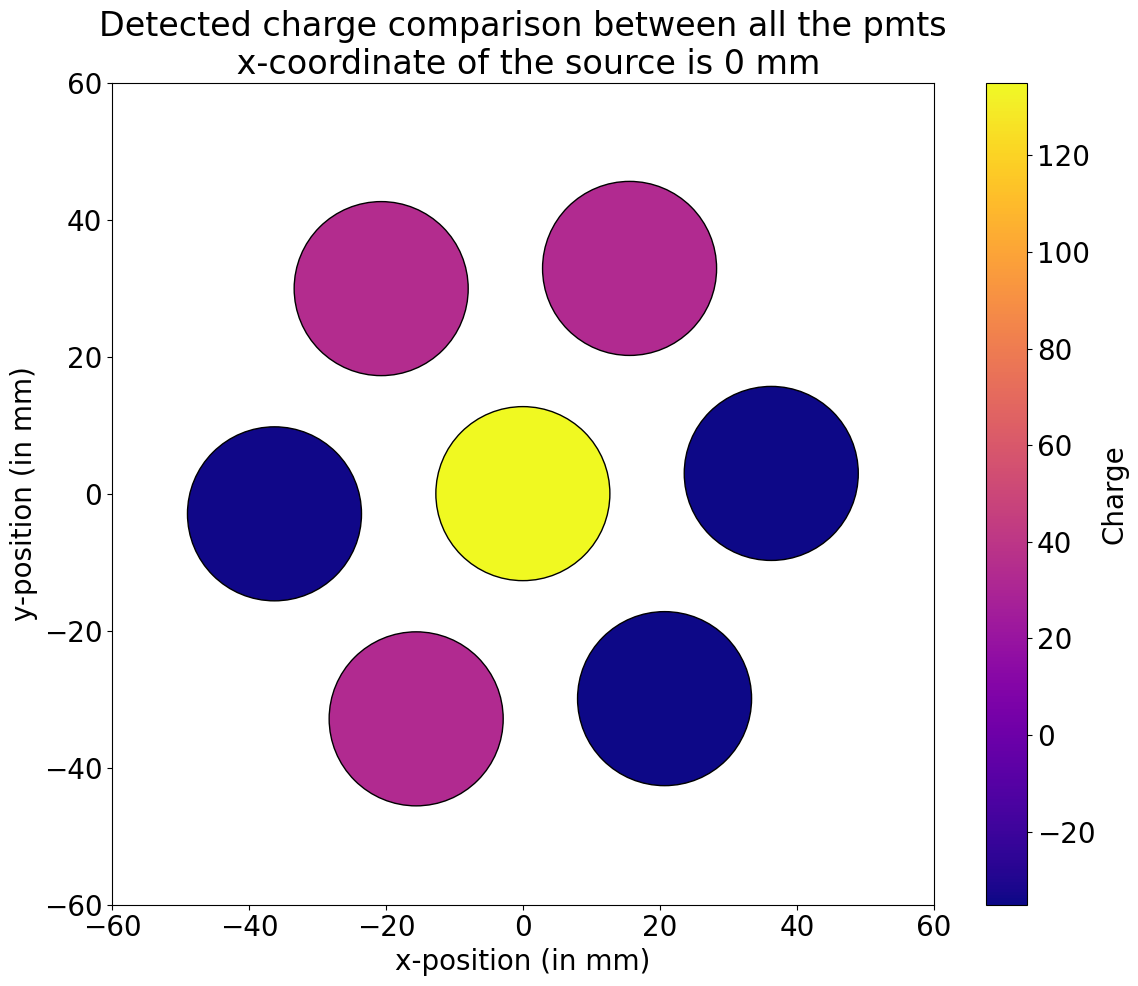

In [223]:
x_coord = np.arange(0,32,2)
pmt_rad = 25.4

positions = [(-15.573, -32.871), (20.68, -29.922), (-36.253, -2.949), (0., 0.), (36.253, 2.949), (-20.68, 29.922), (15.573, 32.871)]       # (x, y) centre des ellipses
sizes = [(pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad)]       # (width, height)
#charges = [10, 25, 5, 5, 5, 5, 5]                      # couleur = charge


patches = []
for (x, y), (w, h) in zip(positions, sizes):
    ellipse = Ellipse((x, y), width=w, height=h)
    patches.append(ellipse)


collection = PatchCollection(patches, cmap='plasma', edgecolor='black')
collection.set_array(np.array(charges))  # couleurs = charges


fig, ax = plt.subplots()
ax.add_collection(collection)
plt.colorbar(collection, ax=ax, label='Charge')


ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_aspect('equal')
plt.xlabel('x-position (in mm)')
plt.ylabel('y-position (in mm)')
plt.title(f'Detected charge comparison between all the pmts\n x-coordinate of the source is {x_coord[0]} mm')
plt.tight_layout()
plt.show()

# Check PMaps (Thekla)

In [224]:
#main_path    = '/home/investigator/GanEss/GanESS_G4Sim/simGanESS/'
#main_path    = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'

#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'
filename_pm  = 'thekla.h5'
#filepath_pm  = main_path + filename_pm
filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_1_thekla.h5'
filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_2_thekla.h5'
#filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_10000_thekla.h5'
filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+run_nb+'_thekla.h5'


!ptdump $filepath_pm
#!ptdump -vd $filepath_pm:/Filters
#!ptdump -v $filepath_pm:/Filters/empty_pmap
#!ptdump -v $filepath_pm:/Filters/s12_indices
#!ptdump -vd $filepath_pm:/PMAPS
#!ptdump -vd $filepath_pm:/PMAPS/S1/
#!ptdump -vd $filepath_pm:/PMAPS/S1Pmt
#!ptdump -vd $filepath_pm:/PMAPS/S2
#!ptdump -v $filepath_pm:/PMAPS/S2Pmt
#!ptdump -v $filepath_pm:/PMAPS/S2Si
#!ptdump -v $filepath_pm:/Run
#!ptdump -v $filepath_pm:/Run/eventMap
#!ptdump -v $filepath_pm:/Run/events
#!ptdump -v $filepath_pm:/Run/runInfo
#!ptdump -v $filepath_pm:/Trigger
#!ptdump -v $filepath_pm:/Trigger/events
#!ptdump -v $filepath_pm:/Trigger/trigger
#!ptdump -v $filepath_pm:/config
#!ptdump -v $filepath_pm:/config/adelma
#!ptdump -v $filepath_pm:/config/thekla




/ (RootGroup) ''
/Filters (Group) ''
/Filters/empty_pmap (Table(7791,)shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/s12_indices (Table(7791,)shuffle, zlib(4)) 'Event has passed filter flag'
/MC (Group) ''
/MC/configuration (Table(34,)shuffle, zlib(4)) ''
/MC/event_mapping (Table(7789,)shuffle, zlib(4)) ''
/MC/hits (Table(143273,)shuffle, zlib(4)) ''
/MC/particles (Table(146032,)shuffle, zlib(4)) ''
/MC/sns_positions (Table(7,)shuffle, zlib(4)) ''
/MC/sns_response (Table(2622521,)shuffle, zlib(4)) ''
/PMAPS (Group) ''
/PMAPS/S1 (Table(331,)shuffle, zlib(4)) 'S1 Table'
/PMAPS/S1Pmt (Table(2317,)shuffle, zlib(4)) 'S1Pmt Table'
/PMAPS/S2 (Table(46222,)shuffle, zlib(4)) 'S2 Table'
/PMAPS/S2Pmt (Table(323554,)shuffle, zlib(4)) 'S2Pmt Table'
/PMAPS/S2Si (Table(0,)shuffle, zlib(4)) 'S2Si Table'
/Run (Group) ''
/Run/eventMap (Table(7789,)shuffle, zlib(4)) ''
/Run/events (Table(7789,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(7789,)shuffle, zlib(4)) 'run info table'
/Tr

In [225]:
pmaps = pmapio.load_pmaps_as_df(filepath_pm) #to read pmaps as panda dataframes
print(pmaps[0])
s1s   = pmaps[0]
#print(s1s)
s2s   = pmaps[1]
evt_list = s1s.event.unique()
#print(evt_list)

     event  peak     time  bwidth       ene
0       14     0  23300.0   100.0  1.661983
1       50     0  23500.0   100.0  1.055649
2      154     0  29800.0   100.0  0.826371
3      213     0  30000.0   100.0  0.710950
4      255     0  24900.0   100.0  1.528984
..     ...   ...      ...     ...       ...
326   7702     0  23100.0   100.0  0.732415
327   7710     0  29700.0   100.0  1.998334
328   7766     0  29500.0   100.0  1.477004
329   7766     0  29600.0   100.0  1.464346
330   7789     0  23500.0   100.0  0.991939

[331 rows x 5 columns]


In [226]:
ns_to_us   = 1000
rebin_size = 10

0


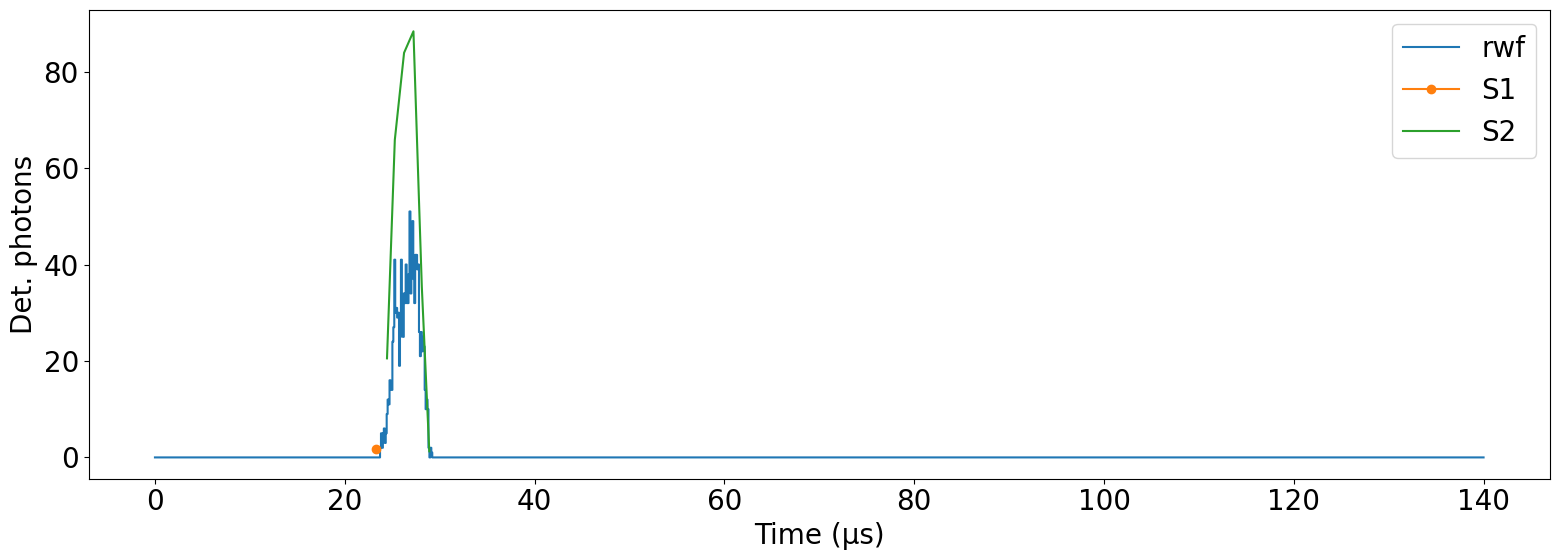

In [227]:
plt.figure(figsize=(16, 6))
evt_number = 0
print(evt_number)
with tb.open_file(filepath_wf, 'r') as h5in:
    pmt_rwf = h5in.root.pmtrd[evt_number][3]#[0]
    t = np.linspace(0, len(pmt_rwf)*pmt_sample_size, len(pmt_rwf))
    plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, label='rwf')
    plt.xlabel('Time (µs)')
    plt.ylabel('Det. photons')

with tb.open_file(filepath_pm, 'r') as h5in:
    s1 = s1s[s1s.event==evt_list[evt_number]]
    s2 = s2s[s2s.event==evt_list[evt_number]]
    #print(s2.time)
    plt.plot(s1.time/ns_to_us, s1.ene, label='S1', marker='o')
    #print(s1.time/ns_to_us, float(s1.ene))
    plt.plot(s2.time/ns_to_us, s2.ene/rebin_size, label='S2')
    plt.xlabel('Time (µs)')
    plt.ylabel('Det. photons')
  
    plt.legend()
plt.tight_layout()

# Check kDST (Theodora)

In [228]:
#main_path    = '/home/investigator/GanEss/GanESS_G4Sim/simGanESS/results/100/'
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_3/simGanESS/'

#filepath_kd  = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_2_theodora.h5'
filepath_kd = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/theodora_100000.h5'
filepath_kd = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+run_nb+'_theodora.h5'

#filename_kd  = 'theodora.h5'
#filepath_kd  = main_path + filename_kd
#filepath_kd  = main_path + filename_pm
!ptdump $filepath_kd
#!ptdump -v $filepath_wf:/pmtrd
!ptdump -v $filepath_kd:/DST/Events
dst = pd.read_hdf(filepath_kd, "/DST/Events")
print(dst['S2e'])




/ (RootGroup) ''
/DST (Group) ''
/DST/Events (Table(245,)shuffle, zlib(4)) 'KDST Events'
/Filters (Group) ''
/Filters/s12_selector (Table(7789,)shuffle, zlib(4)) 'Event has passed filter flag'
/Run (Group) ''
/Run/events (Table(245,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(245,)shuffle, zlib(4)) 'run info table'
/config (Group) ''
/config/adelma (Table(12,)shuffle, zlib(4)) 'configuration for adelma'
/config/thekla (Table(24,)shuffle, zlib(4)) 'configuration for thekla'
/config/theodora (Table(30,)shuffle, zlib(4)) 'configuration for theodora'
/DST/Events (Table(245,)shuffle, zlib(4)) 'KDST Events'
  description := {
  "event": Int64Col(shape=(), dflt=0, pos=0),
  "time": Float64Col(shape=(), dflt=0.0, pos=1),
  "s1_peak": UInt16Col(shape=(), dflt=0, pos=2),
  "s2_peak": UInt16Col(shape=(), dflt=0, pos=3),
  "nS1": UInt16Col(shape=(), dflt=0, pos=4),
  "nS2": UInt16Col(shape=(), dflt=0, pos=5),
  "S1w": Float64Col(shape=(), dflt=0.0, pos=6),
  "S1h": Float64Col(shape=()

In [229]:
dst.tail()

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
240,7668,1.533665e+10,0,0,1,1,100.0,2.391711,2.391711,23300.0,...,0,3.429793,3.429793,1.087236,-7.082851,9.821341,12.108902,2.195589,21.809593,23.851707
241,7702,1.540567e+10,0,0,1,1,100.0,0.732415,0.732415,23100.0,...,0,4.130078,4.130078,1.093607,-7.231235,10.326161,12.606362,2.181712,21.988281,23.741097
242,7710,1.542126e+10,0,0,1,1,100.0,1.998334,1.998334,29700.0,...,0,-3.255399,-3.255399,1.057011,-5.111641,10.111228,11.329864,2.038867,22.329226,23.537498
243,7766,1.553243e+10,0,0,1,1,200.0,1.477004,2.941350,29500.0,...,0,-2.269824,-2.269824,1.068705,-6.876279,9.192277,11.479598,2.213048,21.651328,24.288242
244,7789,1.557915e+10,0,0,1,1,100.0,0.991939,0.991939,23500.0,...,0,4.029854,4.029854,1.071978,-7.230085,9.679509,12.081681,2.212341,21.674252,24.011068


3519.798828125


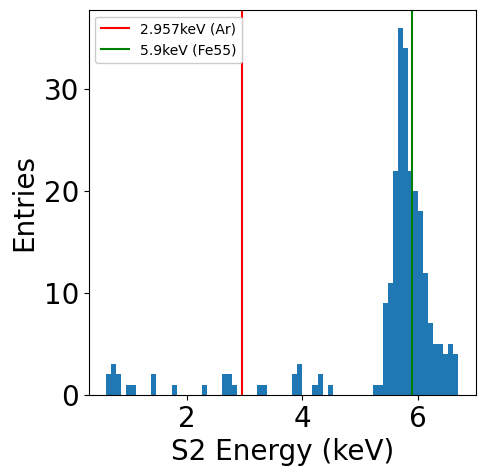

In [232]:
plt.figure(figsize = (5,5))
#S2_ene = dst.S2e * 5.9 / 4605.281066982388
S2_ene = dst.S2e * 5.9 /3098

print(dst.S2e.max())
#S2_ene = dst.S2e * 5.9 / 13956.638672
plt.hist(S2_ene, 70)


plt.xlabel('S2 Energy (keV)')
plt.ylabel('Entries')
#plt.yscale('log')

#ene_line = [1.486, 1.557, 2.957, 5.9]
ene_line = [ 2.957, 5.9]
colors = ['red', 'green', 'blue', 'orange']
labels = ['1.486keV (Al)', '1.557keV (Al)', '2.957keV (Ar)', '5.9keV (Fe55)']
labels = [ '2.957keV (Ar)', '5.9keV (Fe55)']

for ene, color, label in zip(ene_line, colors, labels):
    plt.axvline(ene, color=color, linestyle='-', linewidth=1.5, label=label)
plt.legend(loc='upper left', fontsize=10, framealpha=1)

#print(min(kdst.S2e), max(kdst.S2e))



ValueError: `ydata` must not be empty!

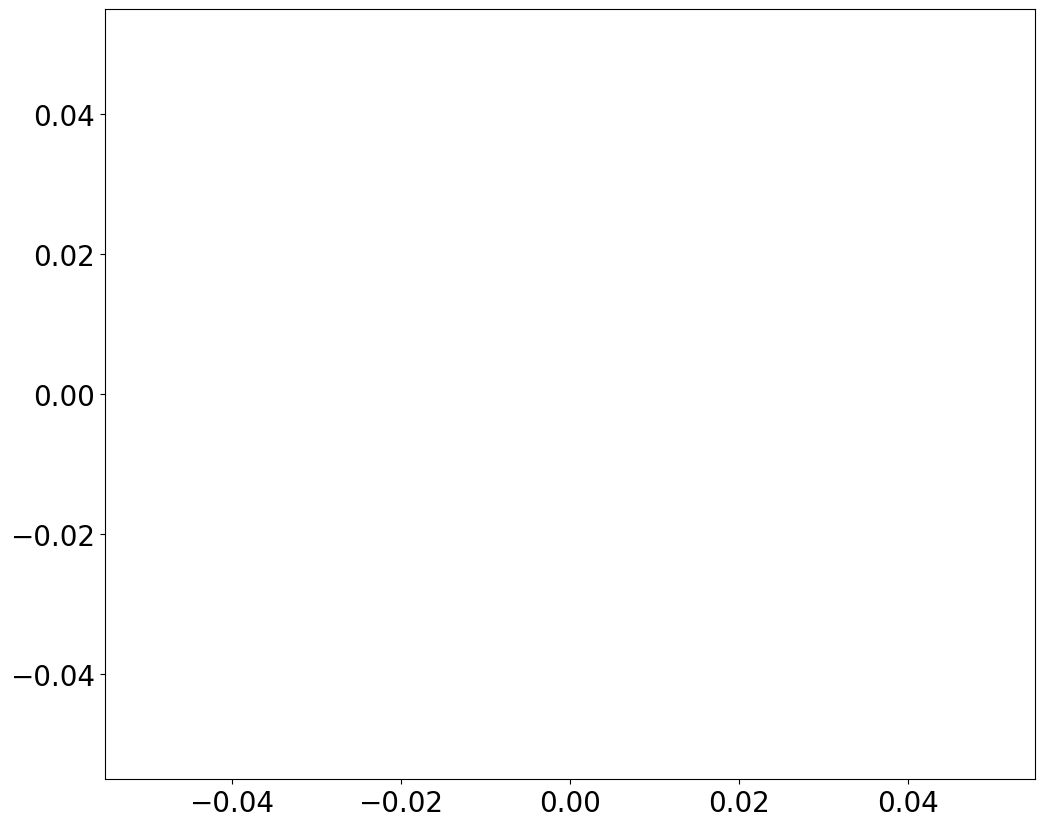

In [231]:
bins_ = np.arange(0, 8, 10)
bin_centers = (bins_[1:] + bins_[:-1]) / 2

def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

n, bins, patches = plt.hist(S2_ene, bins=bins_)
y = n

p0 = (200, 5.9, 2)
popt, pcov = curve_fit(gauss, bin_centers, y, p0=p0)
y_fit = gauss(bin_centers, *popt)
err = np.sqrt(np.diag(pcov))

amp1 = popt[0]
mu1 = popt[1]
sigma1 = popt[2]

amp1_err = err[0]
mu1_err = err[1]
sigma1_err = err[2]

print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')

plt.plot(bin_centers, y_fit, color='r', linestyle='dashed')

plt.xlabel('Charge (mV)')
#plt.xlabel('Nb of AP')
plt.ylabel('Counts')


plt.legend()
plt.show()


In [ ]:
plt.figure()
plt.hist(kdst.S2e, 100);
plt.xlabel('S2 Energy (pes)')
plt.ylabel('Entries')

print(min(kdst.S2e), max(kdst.S2e))

a = 600
b = 1000

gauss2 = []

for values in kdst.S2e:
    if a <= values <= b:
        gauss2.append(values)

plt.figure()
#plt.hist(gauss1, 100);
#plt.xlabel('S2 Energy (pes)')
#plt.ylabel('Entries')

def gauss(x,amp,mu,sigma):
    return amp*np.exp(-(x-mu)**2/(2*sigma**2))

x = np.linspace(a, b, 200)

n,bins,patches = plt.hist(gauss2, bins=200, range=(a,b))
#print(n,bins,patches)

y = n

moy = sum(gauss2)/len(gauss2)
#print("moy", moy)

     

popt, pcov = curve_fit(gauss,x,y,p0=(3.06913166,764.19105183,50.90685136))

y = gauss(x,popt[0],popt[1],popt[2])

plt.plot(x,y,color='r',linestyle='dashed')

print(popt)



#popt,pcov = curve_fit(gauss,x,y,p0=())


In [123]:
plt.figure()
plt.hist(kdst.S1e, 1000);
plt.xlabel('S1 Energy (pes)')

plt.ylabel('Entries')

NameError: name 'kdst' is not defined

<Figure size 1200x1000 with 0 Axes>

In [124]:
print(kdst)

NameError: name 'kdst' is not defined

# Event reconstruction

In [83]:
pmt_rad = 25.4/2 #mm
pmt_PsX= [-15.573, 20.68, -36.253, 0., 36.253, -20.68, 15.573]
pmt_PsY= [-32.871, -29.922, -2.949, 0., 2.949, 29.922, 32.871]

mesh_rad = 104./2 #mm

NameError: name 'kdst' is not defined

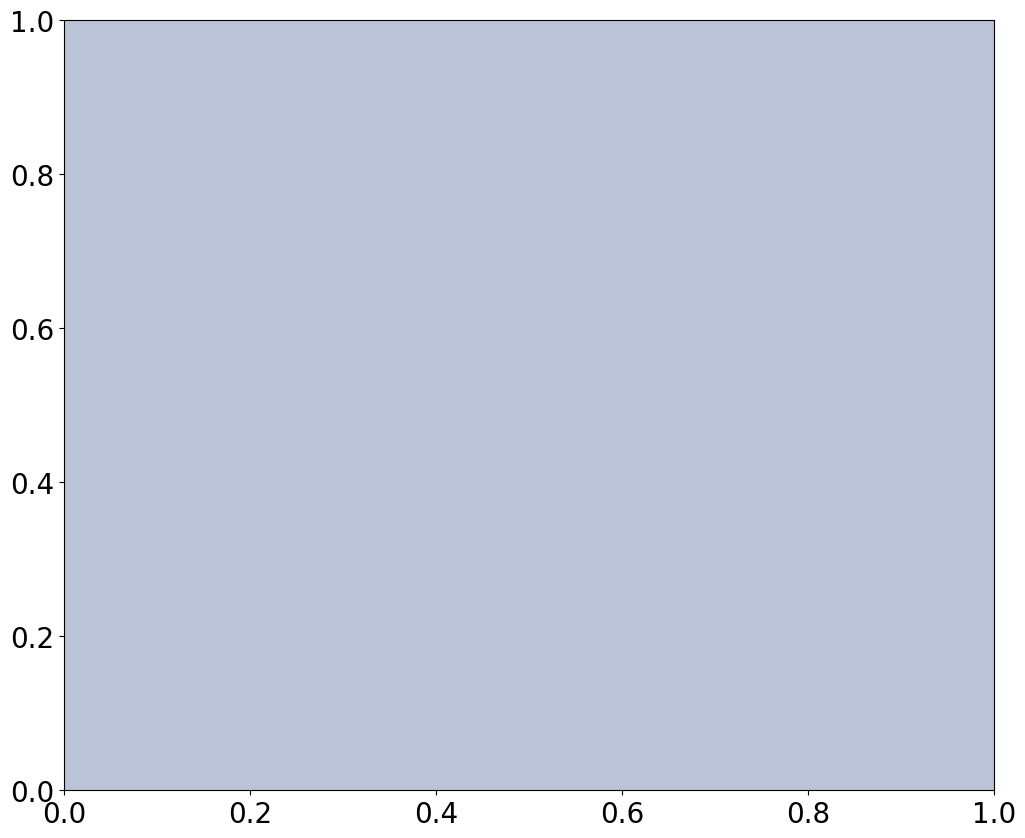

In [84]:
circle_mesh = plt.Circle((0,0), mesh_rad, alpha=0.1, color = 'red')
plt.gca().add_patch(circle_mesh)

circle0 = plt.Circle((pmt_PsX[0],pmt_PsY[0]), pmt_rad, alpha=0.3)
circle1 = plt.Circle((pmt_PsX[1],pmt_PsY[1]), pmt_rad, alpha=0.3)
circle2 = plt.Circle((pmt_PsX[2],pmt_PsY[2]), pmt_rad, alpha=0.3)
circle3 = plt.Circle((pmt_PsX[3],pmt_PsY[3]), pmt_rad, alpha=0.3)
circle4 = plt.Circle((pmt_PsX[4],pmt_PsY[4]), pmt_rad, alpha=0.3)
circle5 = plt.Circle((pmt_PsX[5],pmt_PsY[5]), pmt_rad, alpha=0.3)
circle6 = plt.Circle((pmt_PsX[6],pmt_PsY[6]), pmt_rad, alpha=0.3)
plt.gca().add_patch(circle0)
plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)
plt.gca().add_patch(circle3)
plt.gca().add_patch(circle4)
plt.gca().add_patch(circle5)
plt.gca().add_patch(circle6)

plt.scatter(kdst.X, kdst.Y, color='orange', label = 'RMS positions')
plt.xlabel('X position')
plt.ylabel('Y position')
#plt.legend()

In [85]:
print(kdst.X)

NameError: name 'kdst' is not defined